In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from scipy import stats
from scipy.spatial import cKDTree
from sklearn.linear_model import LinearRegression


In [3]:
data_dir = os.path.expanduser("~/DataFiles")
racmo_smb_file = data_dir + "/smbgl_monthlyS_ANT11_RACMO2.4p1_ERA5_197901_202512.nc"
racmo_t2m_file = data_dir + "/tas_monthlyA_ANT11_RACMO2.4p1_ERA5_197901_202512.nc"
racmo_mask_file = data_dir + "/TotIS_RACMO_ANT27_IMBIE2.nc"
ant11_mask_file = data_dir + "/ANT11_masks.nc"
ant27_ref_file  = data_dir + "/smb_monthlyS_ANT27_ERA5-3H_RACMO2.3p2_197901_202212.nc"
accum_data_file   = data_dir + "/AccumCoresData.csv"
water_data_file   = data_dir + "/WaterCoresData.csv"
accum_coords_file = data_dir + "/AccumCoresCoords.csv"
water_coords_file = data_dir + "/WaterCoresCoords.csv"


In [4]:
smb_ds = xr.open_dataset(racmo_smb_file)
smb_ann = (smb_ds["smbgl"].squeeze("height").groupby("time.year").sum("time").sel(year=slice(1979, 2025)))
t2m_ds = xr.open_dataset(racmo_t2m_file)
t2m_ann = (t2m_ds["tas"].squeeze("height").groupby("time.year").mean("time").sel(year=slice(1979, 2025)))
lat_racmo, lon_racmo = smb_ann["lat"].values, smb_ann["lon"].values
NY, NX = lat_racmo.shape; years_obs = smb_ann["year"].values
print("ANT11 grid:", (NY, NX), " years", int(years_obs.min()), "-", int(years_obs.max()))



ANT11 grid: (591, 726)  years 1979 - 2025


In [5]:
mask_ds = xr.open_dataset(ant11_mask_file)
cell_area_m2 = mask_ds["Area"].values * 1e6
ice_sheet    = mask_ds["Icesheet_Only"].values == 1
def to_xyz(lat, lon):
    la, lo = np.deg2rad(lat), np.deg2rad(lon)
    return np.stack([np.cos(la)*np.cos(lo), np.cos(la)*np.sin(lo), np.sin(la)], -1)
ref27 = xr.open_dataset(ant27_ref_file)["smb"].squeeze("height")
lat27, lon27 = ref27["lat"].values, ref27["lon"].values
gi = xr.open_dataset(racmo_mask_file)["GroundedIce"].values
gi = np.where(np.isfinite(gi), gi, 0).astype(int); _gm = gi > 0
_, _idx = cKDTree(to_xyz(lat27[_gm].ravel(), lon27[_gm].ravel())).query(to_xyz(lat_racmo.ravel(), lon_racmo.ravel()))
basin_mask = np.where(ice_sheet.ravel(), gi[_gm].ravel()[_idx], 0).reshape(NY, NX)
grounded_mask = np.load(os.path.expanduser("~/DataFiles/ANT11_grounded_mask.npy"))
basin_mask = np.where(grounded_mask, basin_mask, 0)      # drop floating ice shelves -> grounded ice only

basin_flat = basin_mask.reshape(-1); valid_cells = basin_flat > 0
basin_ids  = basin_flat[valid_cells].astype(int); basin_ids_unique = np.unique(basin_ids)
region_names = ["AIS", "WAIS", "EAIS", "AP"]
print("grounded cells:", int(valid_cells.sum()))


grounded cells: 101022


In [6]:
def basin_sums_Gt(field3d, years):
    mass = field3d * cell_area_m2
    df = pd.DataFrame(index=list(np.asarray(years)), columns=basin_ids_unique, dtype=float)
    for t, yr in enumerate(np.asarray(years)):
        flat = mass[t].reshape(-1)[valid_cells]
        s = pd.DataFrame({"basin": basin_ids, "m": flat}).groupby("basin")["m"].sum() / 1e12
        df.loc[yr, s.index] = s.values
    return df


In [7]:
smb_basin_obs = basin_sums_Gt(smb_ann.values, years_obs)
ais_rac  = smb_basin_obs.sum(axis=1).astype(float)
wais_rac = smb_basin_obs[[3,7,8,9,10]].sum(axis=1).astype(float)
eais_rac = smb_basin_obs[[1,2,11,12,13,14,15,16,17,18]].sum(axis=1).astype(float)
ap_rac   = smb_basin_obs[[4,5,6]].sum(axis=1).astype(float)
raw_series = {"AIS": ais_rac, "WAIS": wais_rac, "EAIS": eais_rac, "AP": ap_rac}


In [8]:
accum_data_raw = pd.read_csv(accum_data_file, header=None)
water_data_raw = pd.read_csv(water_data_file, header=None)
def extract_cores(raw_df, yr_min, yr_max, transpose=True):
    years_col = raw_df.iloc[2:, 0].astype(int)
    m = (years_col >= yr_min) & (years_col <= yr_max)
    arr = raw_df.iloc[2:, 1:][m].to_numpy()[::-1].astype(float)
    return arr.T if transpose else arr
N_CAL = 42; CAL_YEARS = slice(1979, 2020); recon_years = np.arange(1801, 2001)
accum_cores_cal  = extract_cores(accum_data_raw, 1979, 2020)
water_cores_cal  = extract_cores(water_data_raw, 1979, 2020)
accum_cores_full = extract_cores(accum_data_raw, 1801, 2000, transpose=False)
water_cores_full = extract_cores(water_data_raw, 1801, 2000, transpose=False)
accum_coords = pd.read_csv(accum_coords_file, header=None)
water_coords = pd.read_csv(water_coords_file, header=None)
core_lats  = accum_coords.iloc[:, 2].values; core_lons  = (accum_coords.iloc[:, 3].values + 360) % 360
water_lats = water_coords.iloc[:, 2].values; water_lons = (water_coords.iloc[:, 3].values + 360) % 360
print("accum cores:", accum_cores_full.shape[1], " water cores:", water_cores_full.shape[1])


accum cores: 84  water cores: 80


In [9]:
def nearest_ij(lat2d, lon2d, tlat, tlon):
    lon360 = (lon2d + 360) % 360
    d2 = (lat2d - tlat)**2 + (lon360 - (tlon + 360) % 360)**2
    return np.unravel_index(np.argmin(d2), d2.shape)
smb_cal = smb_ann.sel(year=CAL_YEARS).values; t2m_cal = t2m_ann.sel(year=CAL_YEARS).values
accum_pts = np.zeros((84, N_CAL)); R_accum = np.zeros(84)
for i in range(84):
    j, k = nearest_ij(lat_racmo, lon_racmo, core_lats[i], core_lons[i])
    smb_pt = smb_cal[:, j, k]; obs = accum_cores_cal[i, :]; accum_pts[i, :] = smb_pt
    v = np.isfinite(obs) & np.isfinite(smb_pt)
    reg = LinearRegression().fit(smb_pt[v].reshape(-1,1), obs[v].reshape(-1,1))
    R_accum[i] = np.var(obs[v].reshape(-1,1) - reg.predict(smb_pt[v].reshape(-1,1)), ddof=1)
_valid = np.isfinite(accum_cores_cal) & np.isfinite(accum_pts)
_off = (np.nanmean(np.where(_valid, accum_cores_cal, np.nan), axis=1)
        - np.nanmean(np.where(_valid, accum_pts, np.nan), axis=1))
y_e_accum = accum_pts + _off[:, None]
y_e_water = np.zeros((80, N_CAL)); R_water = np.zeros(80)
for i in range(80):
    j, k = nearest_ij(lat_racmo, lon_racmo, water_lats[i], water_lons[i])
    t_pt = t2m_cal[:, j, k]; obs = water_cores_cal[i, :]
    v = np.isfinite(obs) & np.isfinite(t_pt)
    reg = LinearRegression().fit(t_pt[v].reshape(-1,1), obs[v].reshape(-1,1))
    y_e_water[i, :] = t_pt * reg.coef_[0][0] + reg.intercept_[0]
    R_water[i] = np.var(obs[v].reshape(-1,1) - reg.predict(t_pt[v].reshape(-1,1)), ddof=1)
y_e_smb = np.vstack([y_e_accum, y_e_water]); R_smb_diag = np.concatenate([R_accum, R_water])
proxy_smb = np.hstack([accum_cores_full, water_cores_full])
print("PSMs ready:", y_e_smb.shape)


PSMs ready: (164, 42)


In [10]:
def run_ensrf_spatial_unc(prior_cells, y_e, R_diag_vec, proxy_data_full, n_proxy, integ):
    Ns = prior_cells.shape[1]
    post_mean = np.zeros((200, Ns), np.float32); post_std = np.zeros((200, Ns), np.float32)
    reg_ens = np.zeros((200, N_CAL, integ.shape[0]))
    for i in range(200):
        X_mean = prior_cells.mean(axis=0); X_dev = prior_cells - X_mean
        for j in range(n_proxy):
            if np.isnan(proxy_data_full[i, j]): continue
            y_mean = y_e[j, :].mean(); y_var = np.var(y_e[j, :], ddof=1)
            if not np.isfinite(y_mean) or y_var == 0: continue
            y_dev = y_e[j, :] - y_mean
            K = ((X_dev.T @ y_dev) / (N_CAL - 1)) / (y_var + R_diag_vec[j])
            X_mean = X_mean + K * (proxy_data_full[i, j] - y_mean)
            alpha = 1.0 / (1.0 + np.sqrt(R_diag_vec[j] / (y_var + R_diag_vec[j])))
            X_dev = X_dev - alpha * np.outer(y_dev, K)
        post_mean[i] = X_mean; post_std[i] = X_dev.std(axis=0, ddof=1)
        reg_ens[i] = (integ @ (X_mean[None, :] + X_dev).T).T
    return post_mean, post_std, reg_ens


In [11]:
_va = cell_area_m2.reshape(-1)[valid_cells]
_regions = {"AIS": basin_ids > 0, "WAIS": np.isin(basin_ids,[3,7,8,9,10]),
            "EAIS": np.isin(basin_ids,[1,2,11,12,13,14,15,16,17,18]), "AP": np.isin(basin_ids,[4,5,6])}
A_smb   = np.vstack([np.where(_regions[r], _va, 0) / 1e12 for r in region_names])
A_basin = np.vstack([np.where(basin_ids == b, _va, 0) / 1e12 for b in basin_ids_unique])
A_all   = np.vstack([A_smb, A_basin])

smb_cells = smb_ann.sel(year=CAL_YEARS).values.reshape(N_CAL, -1)[:, valid_cells].astype(np.float32)
print("Running SMB EnSRF (%d grounded cells) ..." % smb_cells.shape[1])
smb_post_v, smb_std_v, reg_ens_all = run_ensrf_spatial_unc(smb_cells, y_e_smb, R_smb_diag, proxy_smb, 164, A_all)

smb_reg_ens_raw   = reg_ens_all[:, :, :4]
smb_basin_ens_raw = reg_ens_all[:, :, 4:]
racmo_smb_recon_raw = np.full((200, NY*NX), np.nan, np.float32)
racmo_smb_recon_raw[:, valid_cells] = smb_post_v
racmo_smb_recon_raw = racmo_smb_recon_raw.reshape(200, NY, NX)
smb_reg_mean_raw = smb_reg_ens_raw.mean(1); smb_reg_std_raw = smb_reg_ens_raw.std(1, ddof=1)
print("Raw reconstruction ready.")



Running SMB EnSRF (101022 grounded cells) ...
Raw reconstruction ready.


In [12]:
W, FMAX, TAPER_YRS = 31, 5.0, 0        # TAPER_YRS>0 ramps the factor back to 1 over N years after the split
SPLIT_YEAR = 1956                      # <-- tweakable: correction applied THROUGH this year (inclusive)
BASE_END   = 1900                      # baseline + GGM window end — held FIXED at 1900

i_split = int(np.clip(SPLIT_YEAR - 1801 + 1, 0, 200))   # first uncorrected index
i_base  = BASE_END - 1801 + 1                            # = 100, fixed

_r = lambda x: pd.Series(np.asarray(x, float)).rolling(W, center=True, min_periods=max(4, W//2))
roll_mean = lambda x: _r(x).mean().values
roll_var  = lambda x: _r(x).var(ddof=1).values
dvar = lambda x: np.var(np.asarray(x,float)-np.polyval(np.polyfit(np.arange(len(x)),np.asarray(x,float),1),
                                                        np.arange(len(x))), ddof=1)

# --- LTV amplitude per region over the FIXED 1801-BASE_END window (feeds the null) ---
reg_var_raw = smb_reg_ens_raw.var(1, ddof=1)
sig_total_ltv = {}
for k, r in enumerate(region_names):
    v_mean = dvar(smb_reg_mean_raw[0:i_base, k]); v_post = reg_var_raw[0:i_base, k].mean()
    sig_total_ltv[r] = np.sqrt(v_mean + v_post)
    print(f"{r}: sigma_mean {np.sqrt(v_mean):6.1f}   LTV total {sig_total_ltv[r]:6.1f}   "
          f"x{sig_total_ltv[r]/np.sqrt(v_mean):.2f}")

# --- per-basin time-varying factor, applied only through SPLIT_YEAR ---
mean_b = smb_basin_ens_raw.mean(1); var_b = smb_basin_ens_raw.var(1, ddof=1)
f_b = np.ones_like(mean_b)
for b in range(mean_b.shape[1]):
    v_mean, v_post = roll_var(mean_b[:, b]), roll_mean(var_b[:, b])
    f = np.sqrt((v_mean + v_post) / np.maximum(v_mean, 1e-12))
    f_b[:, b] = np.clip(pd.Series(f).ffill().bfill().values, 1.0, FMAX)

f_use = f_b.copy()
f_use[i_split:, :] = 1.0                                   # uncorrected from SPLIT_YEAR+1 onward
if TAPER_YRS > 0:                                          # optional smooth hand-off at the split
    f_edge = f_b[max(i_split-1, 0), :]
    for j in range(TAPER_YRS):
        i = i_split + j
        if i < f_use.shape[0]:
            f_use[i, :] = 1.0 + (f_edge - 1.0) * (1.0 - (j+1)/TAPER_YRS)
print(f"split at {SPLIT_YEAR}: factor there = {f_b[max(i_split-1,0)].mean():.2f}  "
      f"(set TAPER_YRS>0 to smooth the hand-off)")

# --- build the working series: corrected mean, spread preserved; baseline fixed to 1801-BASE_END ---
base_b   = mean_b[0:i_base].mean(0)
mean_cor = base_b + (mean_b - base_b) * f_use
smb_basin_ens = mean_cor[:, None, :] + (smb_basin_ens_raw - mean_b[:, None, :])
bcol = {b: i for i, b in enumerate(basin_ids_unique)}
reg_cols = {"AIS":  [bcol[b] for b in basin_ids_unique],
            "WAIS": [bcol[b] for b in [3,7,8,9,10] if b in bcol],
            "EAIS": [bcol[b] for b in [1,2,11,12,13,14,15,16,17,18] if b in bcol],
            "AP":   [bcol[b] for b in [4,5,6] if b in bcol]}
smb_reg_ens  = np.stack([smb_basin_ens[:, :, reg_cols[r]].sum(2) for r in region_names], axis=2)
smb_reg_mean = smb_reg_ens.mean(1); smb_reg_std = smb_reg_ens.std(1, ddof=1)
ais_rac_recon, wais_rac_recon, eais_rac_recon, ap_rac_recon = (smb_reg_mean[:, k] for k in range(4))
ais_rac_std,  wais_rac_std,  eais_rac_std,  ap_rac_std      = (smb_reg_std[:, k]  for k in range(4))
smb_std_by_region = {"AIS": ais_rac_std, "WAIS": wais_rac_std, "EAIS": eais_rac_std, "AP": ap_rac_std}
recon_series = {"AIS": ais_rac_recon, "WAIS": wais_rac_recon, "EAIS": eais_rac_recon, "AP": ap_rac_recon}

bcell = np.full((NY, NX), -1, int)
for i, b in enumerate(basin_ids_unique): bcell[basin_mask == b] = i
valid2d = bcell >= 0
cellmean = np.nanmean(racmo_smb_recon_raw[:i_base], axis=0)
fcell = f_use[:, np.where(valid2d, bcell, 0)]; fcell[:, ~valid2d] = 1.0
racmo_smb_recon = cellmean[None] + (racmo_smb_recon_raw - cellmean[None]) * fcell
smb_basin_recon = basin_sums_Gt(racmo_smb_recon, recon_years)
print(f"Working series: LTV-corrected 1801-{SPLIT_YEAR}, raw {SPLIT_YEAR+1}-2000.")






AIS: sigma_mean   87.1   LTV total  108.0   x1.24
WAIS: sigma_mean   82.7   LTV total   85.7   x1.04
EAIS: sigma_mean   69.2   LTV total   90.1   x1.30
AP: sigma_mean   30.9   LTV total   36.4   x1.18
split at 1956: factor there = 1.19  (set TAPER_YRS>0 to smooth the hand-off)


/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_65399/3291816055.py:61: RuntimeWarning: Mean of empty slice
  cellmean = np.nanmean(racmo_smb_recon_raw[:i_base], axis=0)


Working series: LTV-corrected 1801-1956, raw 1957-2000.


In [13]:
def _ggm_psi(kappa, phi, K):
    d = 0.5*kappa; a = 1.0-phi; psi = np.empty(K); psi[0] = 1.0
    for k in range(1, K): psi[k] = psi[k-1]*(d+k-1.0)/k*a
    return psi
def _ggm_acf(kappa, phi, n, K=None):
    if K is None: K = int(min(20000, max(2000, 30*n if phi > 0.02 else 20000)))
    psi = _ggm_psi(kappa, phi, K+n)
    return np.array([np.dot(psi[:K], psi[h:h+K]) for h in range(n)])
def _toeplitz(r):
    n = len(r); idx = np.abs(np.arange(n)[:, None] - np.arange(n)[None, :]); return r[idx]
def ggm_fit(x, kappa0=1.0, phi0=0.1, bounds=((0.0,4.0),(1e-4,1.0))):
    from scipy.optimize import minimize
    x = np.asarray(x, float); x = x - x.mean(); n = len(x)
    def negll(th):
        r = _ggm_acf(th[0], th[1], n)
        try: L = np.linalg.cholesky(_toeplitz(r))
        except np.linalg.LinAlgError: return 1e12
        z = np.linalg.solve(L, x); s2 = (z@z)/n
        return 0.5*(n*np.log(2*np.pi*s2) + 2.0*np.log(np.diag(L)).sum() + n)
    res = minimize(negll, [kappa0, phi0], method="L-BFGS-B", bounds=bounds)
    r = _ggm_acf(*res.x, n); L = np.linalg.cholesky(_toeplitz(r)); z = np.linalg.solve(L, x)
    return dict(kappa=res.x[0], phi=res.x[1], sigma_w=np.sqrt((z@z)/n))

ggm_fits = {}
for k, r in enumerate(region_names):
    f_raw = ggm_fit(smb_reg_mean_raw[0:100, k])                    # SHAPE from RAW mean (old)
    f     = ggm_fit(smb_reg_mean[0:100, k])                        # SHAPE from VARIANCE-CORRECTED mean (new)
    marg = np.sqrt(_ggm_acf(f["kappa"], f["phi"], 1)[0]) * f["sigma_w"]
    f["sigma_w"] *= sig_total_ltv[r] / marg                        # AMPLITUDE from LTV (unchanged)
    ggm_fits[r] = f
    print(f"{r}: kappa {f['kappa']:.2f} (raw was {f_raw['kappa']:.2f})  phi {f['phi']:.3f}  "
          f"sigma_w {f['sigma_w']:.1f}  (= LTV {sig_total_ltv[r]:.1f})")





AIS: kappa 0.00 (raw was 0.00)  phi 1.000  sigma_w 108.0  (= LTV 108.0)
WAIS: kappa 0.00 (raw was 0.00)  phi 1.000  sigma_w 85.7  (= LTV 85.7)
EAIS: kappa 0.00 (raw was 0.00)  phi 1.000  sigma_w 90.1  (= LTV 90.1)
AP: kappa 0.63 (raw was 0.63)  phi 0.014  sigma_w 32.6  (= LTV 36.4)


/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


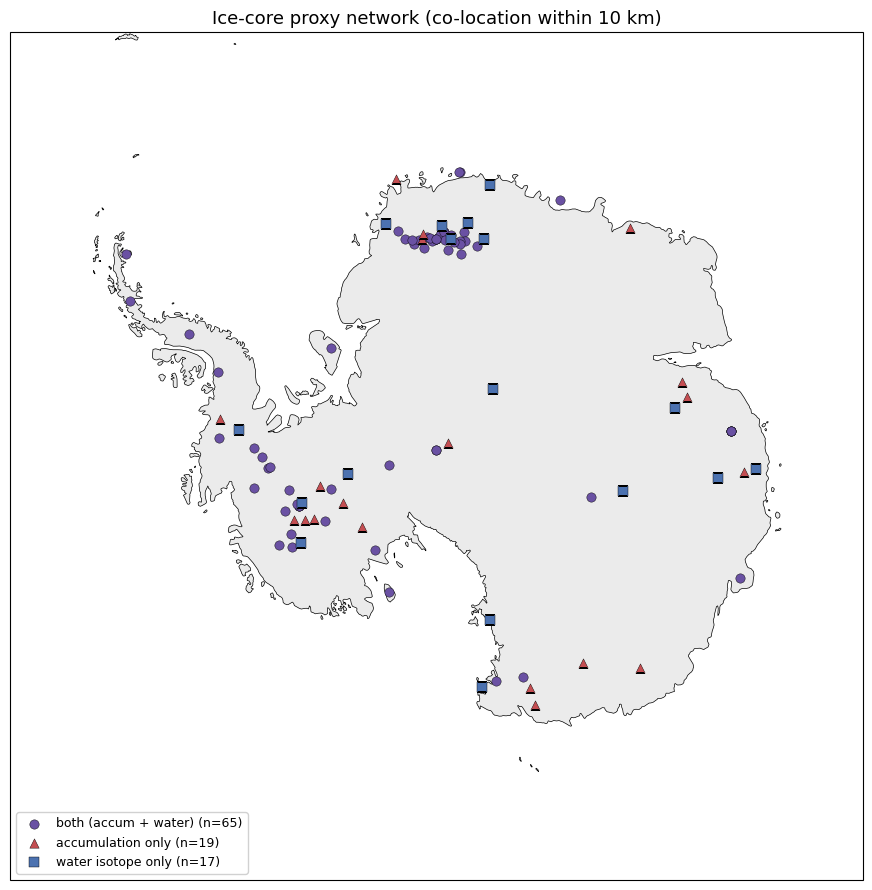

In [14]:
_xyz = lambda lat, lon: np.stack([np.cos(np.deg2rad(lat))*np.cos(np.deg2rad(lon)),
                                  np.cos(np.deg2rad(lat))*np.sin(np.deg2rad(lon)), np.sin(np.deg2rad(lat))], -1)
chord_km = lambda d: 2*np.arcsin(np.clip(d/2, 0, 1))*6371.0
MATCH_KM = 10.0
acc_xyz, wat_xyz = _xyz(core_lats, core_lons), _xyz(water_lats, water_lons)
acc_has_water = chord_km(cKDTree(wat_xyz).query(acc_xyz)[0]) < MATCH_KM
wat_has_acc   = chord_km(cKDTree(acc_xyz).query(wat_xyz)[0]) < MATCH_KM
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": ccrs.SouthPolarStereo()})
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0); ax.add_feature(cfeature.LAND, facecolor="0.92", zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
for lon, lat, c, mk, lbl in [
        (core_lons[acc_has_water], core_lats[acc_has_water], "#6A51A3", "o", "both (accum + water)"),
        (core_lons[~acc_has_water], core_lats[~acc_has_water], "#C44E52", "^", "accumulation only"),
        (water_lons[~wat_has_acc], water_lats[~wat_has_acc], "#4C72B0", "s", "water isotope only")]:
    ax.scatter(lon, lat, s=45, c=c, marker=mk, edgecolor="k", linewidth=0.3,
               transform=ccrs.PlateCarree(), zorder=3, label=f"{lbl} (n={len(lon)})")
ax.legend(loc="lower left", fontsize=9, framealpha=0.9)
ax.set_title(f"Ice-core proxy network (co-location within {MATCH_KM:.0f} km)", fontsize=13)
plt.tight_layout(); plt.show()


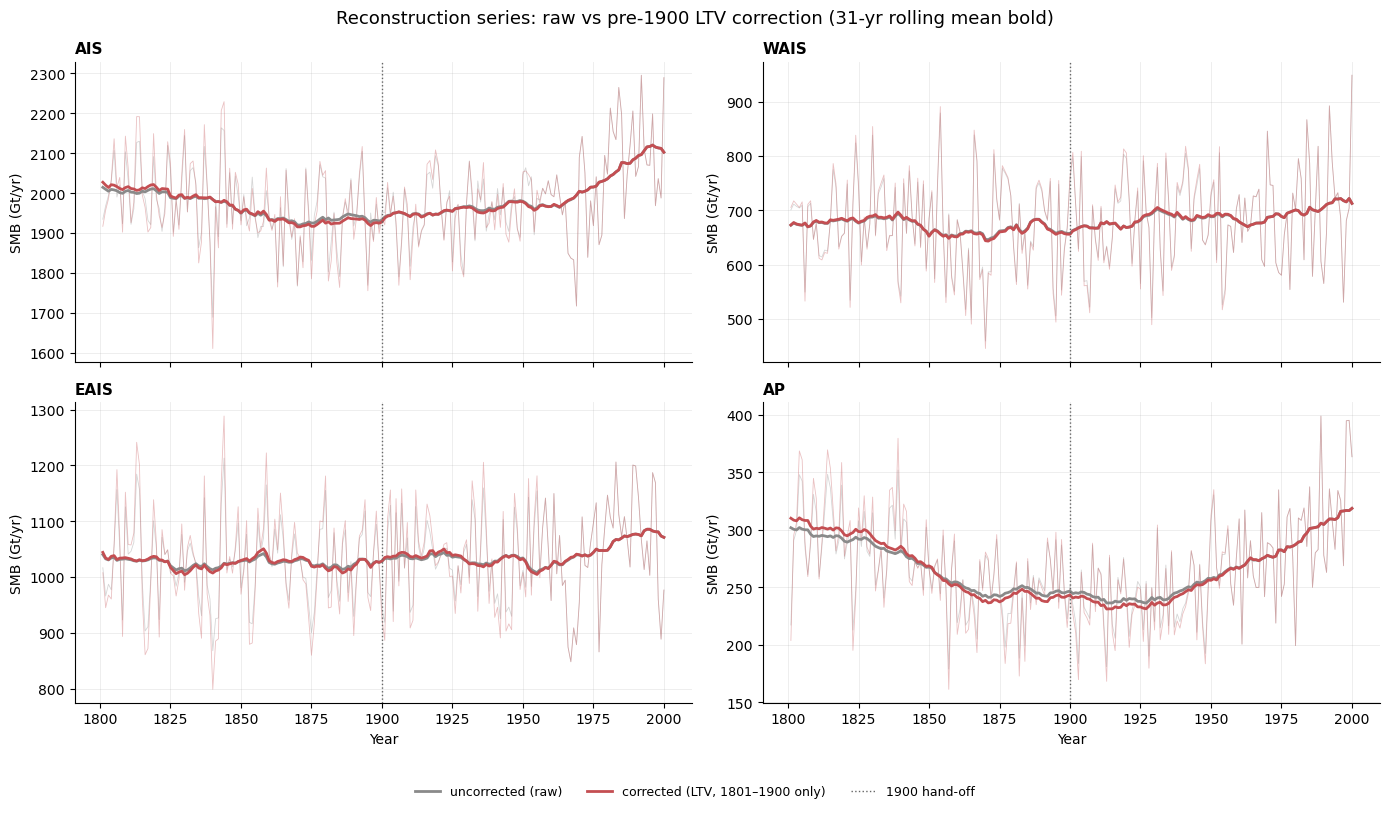

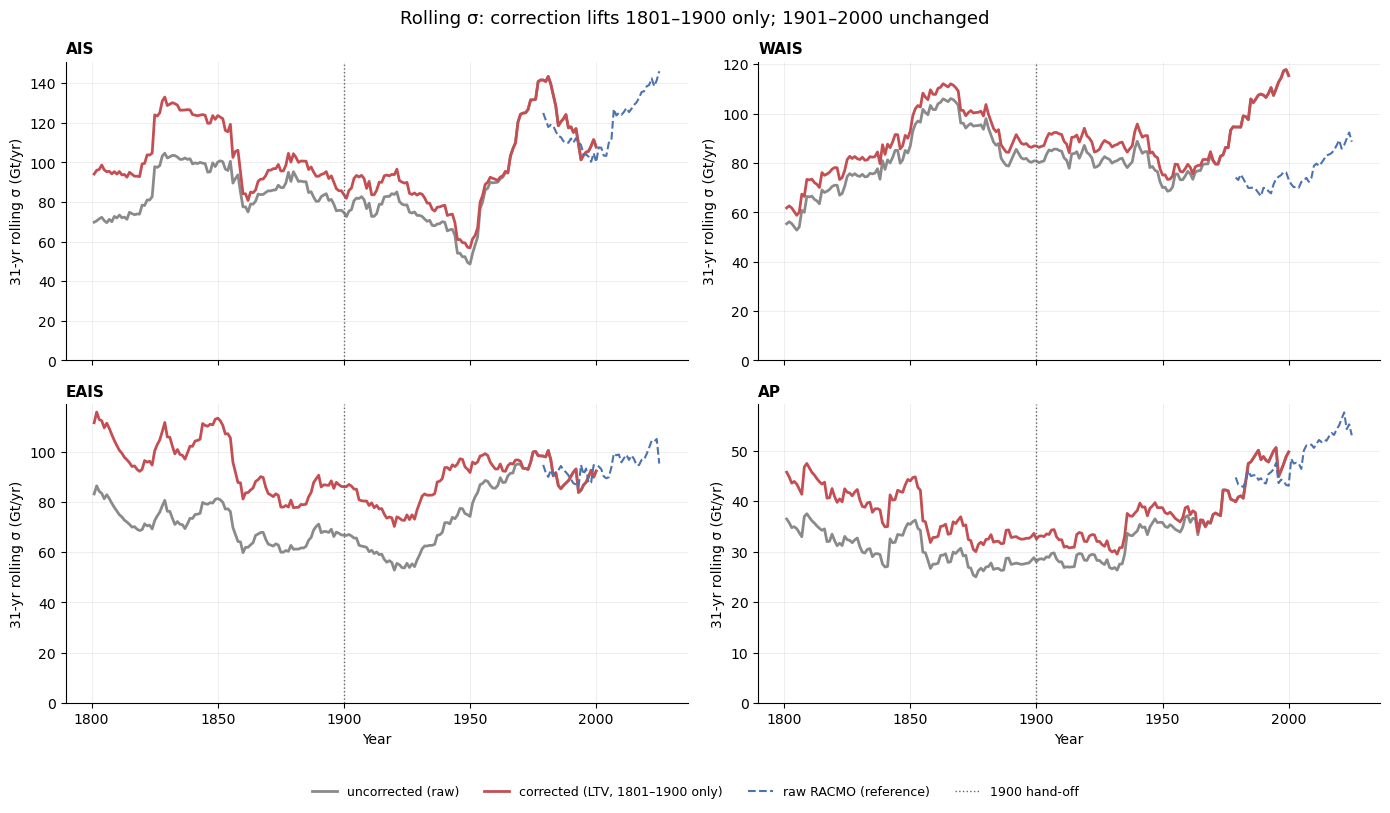

In [15]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

Wr = 31
_rr = lambda x: pd.Series(np.asarray(x, float)).rolling(Wr, center=True, min_periods=max(4, Wr//2))
r_mean = lambda x: _rr(x).mean().values
r_std  = lambda x: _rr(x).std(ddof=1).values
years_r = np.arange(1801, 1801 + smb_reg_mean.shape[0])
C_RAW, C_COR, C_REF = "#8a8a8a", "#C44E52", "#4C72B0"

# --- Figure 1: series (annual faint, 31-yr rolling mean bold) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, (k, r) in zip(axes.ravel(), enumerate(region_names)):
    ax.plot(years_r, smb_reg_mean_raw[:, k], color=C_RAW, lw=0.6, alpha=0.35)
    ax.plot(years_r, smb_reg_mean[:, k],     color=C_COR, lw=0.6, alpha=0.35)
    ax.plot(years_r, r_mean(smb_reg_mean_raw[:, k]), color=C_RAW, lw=2)
    ax.plot(years_r, r_mean(smb_reg_mean[:, k]),     color=C_COR, lw=2)
    ax.axvline(1900, color="0.4", lw=1.0, ls=":")
    ax.set_title(r, fontsize=11, fontweight="bold", loc="left")
    ax.set_ylabel("SMB (Gt/yr)"); ax.grid(alpha=0.25, lw=0.6)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
for ax in axes[-1, :]: ax.set_xlabel("Year")
fig.legend(handles=[Line2D([0],[0], color=C_RAW, lw=2, label="uncorrected (raw)"),
                    Line2D([0],[0], color=C_COR, lw=2, label="corrected (LTV, 1801–1900 only)"),
                    Line2D([0],[0], color="0.4", lw=1.0, ls=":", label="1900 hand-off")],
           loc="lower center", ncol=3, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"Reconstruction series: raw vs pre-1900 LTV correction ({Wr}-yr rolling mean bold)", fontsize=13)
fig.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()

# --- Figure 2: rolling standard deviation, with the raw-RACMO reference ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, (k, r) in zip(axes.ravel(), enumerate(region_names)):
    ax.plot(years_r, r_std(smb_reg_mean_raw[:, k]), color=C_RAW, lw=2)
    ax.plot(years_r, r_std(smb_reg_mean[:, k]),     color=C_COR, lw=2)
    ry = raw_series[r].index.values
    ax.plot(ry, _rr(raw_series[r].values).std(ddof=1).values, color=C_REF, lw=1.5, ls="--")
    ax.axvline(1900, color="0.4", lw=1.0, ls=":")
    ax.set_title(r, fontsize=11, fontweight="bold", loc="left")
    ax.set_ylabel(f"{Wr}-yr rolling σ (Gt/yr)"); ax.set_ylim(bottom=0)
    ax.grid(alpha=0.25, lw=0.6)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
for ax in axes[-1, :]: ax.set_xlabel("Year")
fig.legend(handles=[Line2D([0],[0], color=C_RAW, lw=2, label="uncorrected (raw)"),
                    Line2D([0],[0], color=C_COR, lw=2, label="corrected (LTV, 1801–1900 only)"),
                    Line2D([0],[0], color=C_REF, lw=1.5, ls="--", label="raw RACMO (reference)"),
                    Line2D([0],[0], color="0.4", lw=1.0, ls=":", label="1900 hand-off")],
           loc="lower center", ncol=4, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Rolling σ: correction lifts 1801–1900 only; 1901–2000 unchanged", fontsize=13)
fig.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()


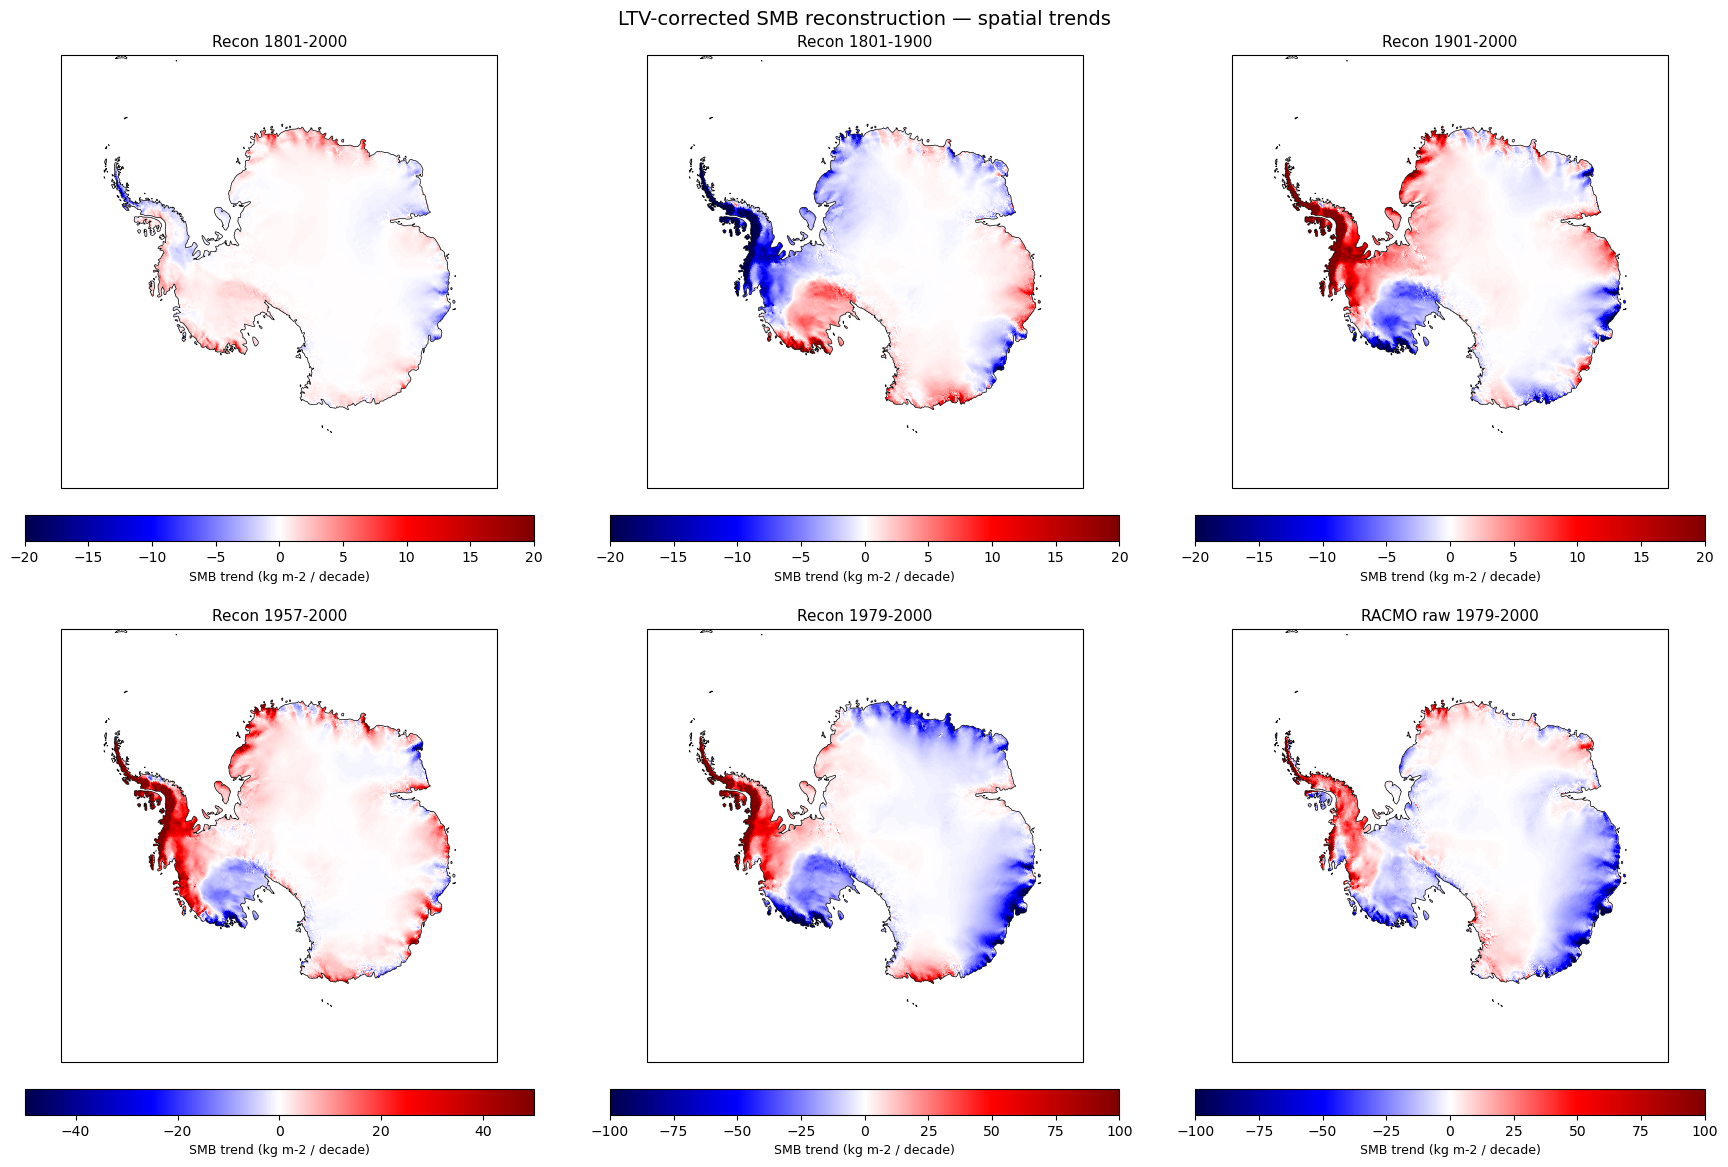

In [88]:
def spatial_trend(cube_3d, yr_start, yr_end, yr_offset=1801):
    sub = cube_3d[yr_start-yr_offset:yr_end-yr_offset+1]
    t = np.arange(sub.shape[0], dtype=float); X = np.vstack([t, np.ones_like(t)]).T
    beta, *_ = np.linalg.lstsq(X, sub.reshape(sub.shape[0], -1), rcond=None)
    return beta[0].reshape(sub.shape[1], sub.shape[2]) * 10

def six_panel(recon_cube, raw_da, cbar_label, cmap, vmaxes, suptitle):
    periods = [("Recon 1801-2000", recon_cube, 1801, 2000, vmaxes[0], 1801),
               ("Recon 1801-1900", recon_cube, 1801, 1900, vmaxes[1], 1801),
               ("Recon 1901-2000", recon_cube, 1901, 2000, vmaxes[2], 1801),
               ("Recon 1957-2000", recon_cube, 1958, 2000, vmaxes[3], 1801),
               ("Recon 1979-2000", recon_cube, 1979, 2000, vmaxes[4], 1801),
               ("RACMO raw 1979-2000", raw_da.sel(year=slice(1979,2000)).values, 1979, 2000, vmaxes[5], 1979)]
    fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={"projection": ccrs.SouthPolarStereo()})
    for ax, (title, cube, y0, y1, vmax, off) in zip(axes.ravel(), periods):
        ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
        im = ax.pcolormesh(lon_racmo, lat_racmo, spatial_trend(cube, y0, y1, off),
                           transform=ccrs.PlateCarree(), vmin=-vmax, vmax=vmax, cmap=cmap, zorder=1)
        ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2); ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
        ax.set_title(title, fontsize=11, pad=6)
        fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.85).set_label(cbar_label, fontsize=9)
    fig.suptitle(suptitle, fontsize=14); fig.tight_layout(); plt.show()

six_panel(racmo_smb_recon, smb_ann, "SMB trend (kg m-2 / decade)", "seismic",
          [20, 20, 20, 50, 100, 100], "LTV-corrected SMB reconstruction — spatial trends")


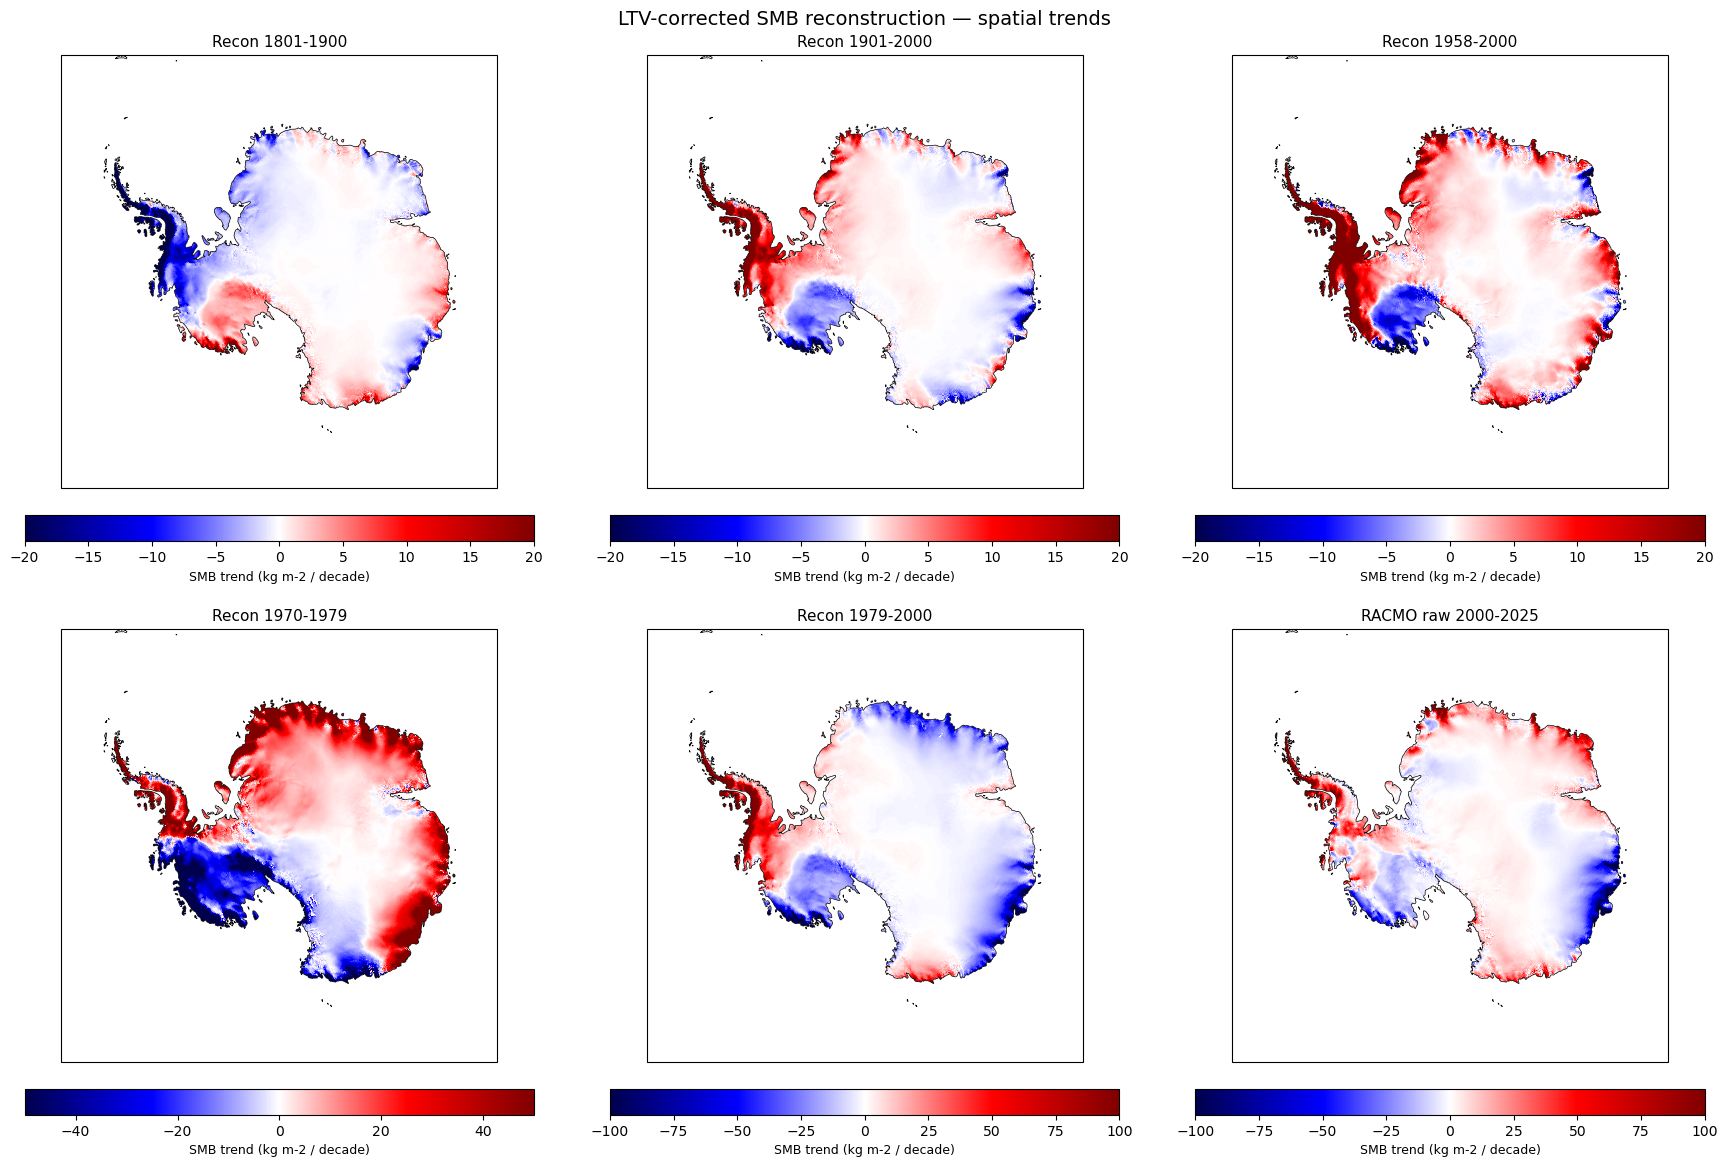

In [93]:
def spatial_trend(cube_3d, yr_start, yr_end, yr_offset=1801):
    sub = cube_3d[yr_start-yr_offset:yr_end-yr_offset+1]
    t = np.arange(sub.shape[0], dtype=float); X = np.vstack([t, np.ones_like(t)]).T
    beta, *_ = np.linalg.lstsq(X, sub.reshape(sub.shape[0], -1), rcond=None)
    return beta[0].reshape(sub.shape[1], sub.shape[2]) * 10

def six_panel(recon_cube, raw_da, cbar_label, cmap, vmaxes, suptitle):
    periods = [("Recon 1801-1900", recon_cube, 1801, 1900, vmaxes[0], 1801),
               ("Recon 1901-2000", recon_cube, 1901, 2000, vmaxes[1], 1801),
               ("Recon 1958-2000", recon_cube, 1958, 2000, vmaxes[2], 1801),
               ("Recon 1970-1979", recon_cube, 1965, 1979, vmaxes[3], 1801),
               ("Recon 1979-2000", recon_cube, 1979, 2000, vmaxes[4], 1801),
               ("RACMO raw 2000-2025", raw_da.sel(year=slice(2000,2025)).values, 1979, 2000, vmaxes[5], 1979)]
    fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={"projection": ccrs.SouthPolarStereo()})
    for ax, (title, cube, y0, y1, vmax, off) in zip(axes.ravel(), periods):
        ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
        im = ax.pcolormesh(lon_racmo, lat_racmo, spatial_trend(cube, y0, y1, off),
                           transform=ccrs.PlateCarree(), vmin=-vmax, vmax=vmax, cmap=cmap, zorder=1)
        ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2); ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
        ax.set_title(title, fontsize=11, pad=6)
        fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.85).set_label(cbar_label, fontsize=9)
    fig.suptitle(suptitle, fontsize=14); fig.tight_layout(); plt.show()

six_panel(racmo_smb_recon, smb_ann, "SMB trend (kg m-2 / decade)", "seismic",
          [20, 20, 20, 50, 100, 100], "LTV-corrected SMB reconstruction — spatial trends")


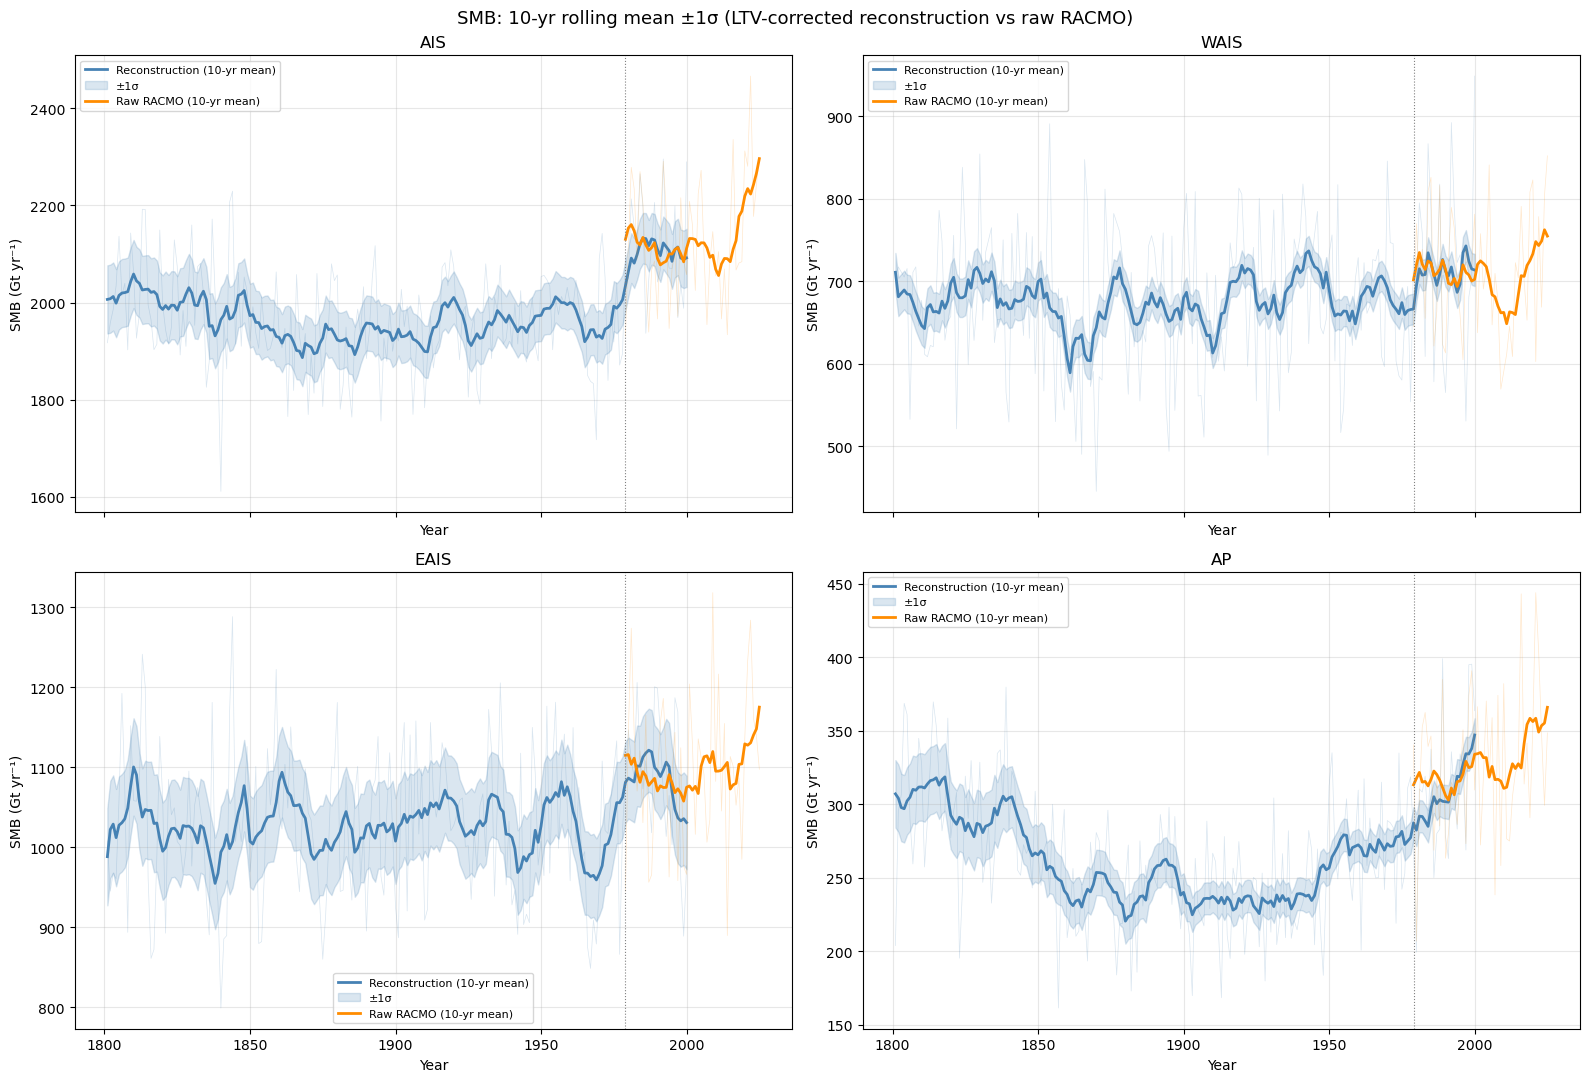

In [17]:
rolling_mean = lambda ts, w=10: pd.Series(ts).rolling(w, center=True, min_periods=1).mean().values
smb_pairs = [(r, recon_series[r], raw_series[r]) for r in region_names]
obs_years_plot = np.arange(1979, 2026)
fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True)
for ax, (region, recon_ts, obs_full) in zip(axes.ravel(), smb_pairs):
    rm = rolling_mean(recon_ts); band = rolling_mean(smb_std_by_region[region])
    ax.plot(recon_years, recon_ts, color="steelblue", lw=0.5, alpha=0.2)
    ax.plot(recon_years, rm, color="steelblue", lw=2.0, label="Reconstruction (10-yr mean)")
    ax.fill_between(recon_years, rm-band, rm+band, color="steelblue", alpha=0.2, label="±1σ")
    ax.plot(obs_years_plot, np.asarray(obs_full), color="darkorange", lw=0.5, alpha=0.2)
    ax.plot(obs_years_plot, rolling_mean(np.asarray(obs_full)), color="darkorange", lw=2.0, label="Raw RACMO (10-yr mean)")
    ax.axvline(1979, color="gray", lw=0.8, ls=":"); ax.set_title(region)
    ax.set_ylabel("SMB (Gt yr⁻¹)"); ax.set_xlabel("Year"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle("SMB: 10-yr rolling mean ±1σ (LTV-corrected reconstruction vs raw RACMO)", fontsize=13)
fig.tight_layout(); plt.show()


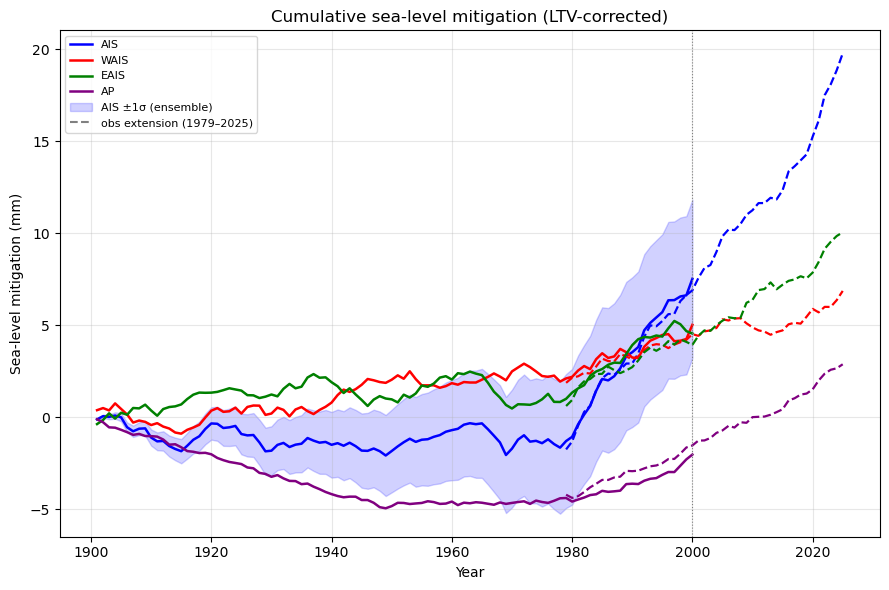

In [18]:
def sea_level_mitigation(ts, baseline=slice(0, 100)):
    ts = np.asarray(ts, float); return np.cumsum(ts - ts[baseline].mean()) / 361.8
def extend_slm(recon_ts, obs_ts, baseline=slice(0, 100)):
    r = np.asarray(recon_ts, float); base = r[baseline].mean(); cum = np.sum(r[:178] - base) / 361.8
    return cum + np.cumsum((np.asarray(obs_ts) - base) / 361.8)
ens = smb_reg_ens[:, :, 0]
slm_std = np.stack([sea_level_mitigation(ens[:, m]) for m in range(ens.shape[1])]).std(0, ddof=1)
slm_ais = sea_level_mitigation(ais_rac_recon); cent_years = np.arange(1901, 2001)
fig, ax = plt.subplots(figsize=(9, 6))
for r, col in zip(region_names, ["blue", "red", "green", "purple"]):
    ax.plot(cent_years, sea_level_mitigation(recon_series[r])[100:], color=col, lw=1.8, label=r)
    ax.plot(years_obs, extend_slm(recon_series[r], raw_series[r]), color=col, lw=1.6, ls="--")
ax.fill_between(cent_years, (slm_ais-slm_std)[100:], (slm_ais+slm_std)[100:], color="blue", alpha=0.18,
                label="AIS ±1σ (ensemble)")
ax.plot([], [], color="gray", lw=1.5, ls="--", label="obs extension (1979–2025)")
ax.axvline(2000, color="gray", lw=0.8, ls=":")
ax.set_xlabel("Year"); ax.set_ylabel("Sea-level mitigation (mm)")
ax.set_title("Cumulative sea-level mitigation (LTV-corrected)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [19]:
import glob
from scipy.interpolate import RegularGridInterpolator
mfiles = sorted(f for f in glob.glob(os.path.expanduser("~/DataFiles/M2TMNXFLX/*")) if f.endswith((".nc4", ".dap.nc4")))
merra_ds = xr.concat([xr.open_dataset(f) for f in mfiles], dim="time")
secs = merra_ds["time"].dt.days_in_month * 86400.0
merra_acc = ((merra_ds["PRECTOT"] * secs).groupby("time.year").sum("time").sel(year=slice(1979, 2025)))
def regrid_to_ant11(da):
    mlat, mlon, vals = da["lat"].values, da["lon"].values, da.values
    if mlat[0] > mlat[-1]: mlat = mlat[::-1]; vals = vals[:, ::-1, :]
    if mlon[0] > mlon[-1]: mlon = mlon[::-1]; vals = vals[:, :, ::-1]
    pts = np.stack([lat_racmo.ravel(), np.clip(lon_racmo.ravel(), mlon.min(), mlon.max())], -1)
    out = np.empty((vals.shape[0], NY, NX))
    for t in range(vals.shape[0]):
        out[t] = RegularGridInterpolator((mlat, mlon), vals[t], bounds_error=False, fill_value=np.nan)(pts).reshape(NY, NX)
    return xr.DataArray(out, dims=("year","rlat","rlon"), coords={"year": da["year"].values})
merra_ann = regrid_to_ant11(merra_acc); print("MERRA-2 on ANT11:", merra_ann.shape)


MERRA-2 on ANT11: (43, 591, 726)


/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_65399/1829690748.py:2: RuntimeWarning: Mean of empty slice
  ra = rec - np.nanmean(rec, axis=0); oa = obs - np.nanmean(obs, axis=0)
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_65399/1829690748.py:2: RuntimeWarning: Mean of empty slice
  ra = rec - np.nanmean(rec, axis=0); oa = obs - np.nanmean(obs, axis=0)


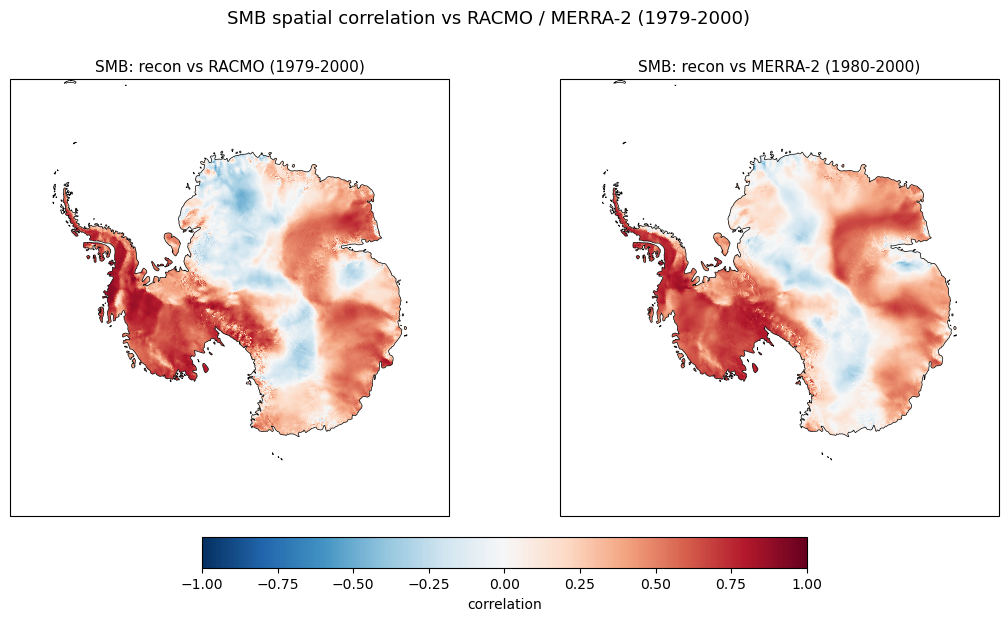

In [20]:
def spatial_corr(rec, obs):
    ra = rec - np.nanmean(rec, axis=0); oa = obs - np.nanmean(obs, axis=0)
    num = np.nansum(ra*oa, axis=0); den = np.sqrt(np.nansum(ra**2, axis=0)*np.nansum(oa**2, axis=0))
    with np.errstate(invalid="ignore"): return np.where(den > 0, num/den, np.nan)
def _align(cube, obs_da, y0=1979, y1=2000):
    yrs = [y for y in range(y0, y1+1) if y in obs_da["year"].values]
    return cube[[y-1801 for y in yrs]], obs_da.sel(year=yrs).values, (yrs[0], yrs[-1])
fig, axes = plt.subplots(1, 2, figsize=(13, 7), subplot_kw={"projection": ccrs.SouthPolarStereo()})
im = None
for ax, (src, da) in zip(axes, [("RACMO", smb_ann), ("MERRA-2", merra_ann)]):
    rec, obs, (ya, yb) = _align(racmo_smb_recon, da)
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = ax.pcolormesh(lon_racmo, lat_racmo, spatial_corr(rec, obs), transform=ccrs.PlateCarree(),
                       vmin=-1, vmax=1, cmap="RdBu_r", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2); ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.set_title(f"SMB: recon vs {src} ({ya}-{yb})", fontsize=11)
fig.colorbar(im, ax=axes, orientation="horizontal", pad=0.04, shrink=0.6).set_label("correlation")
fig.suptitle("SMB spatial correlation vs RACMO / MERRA-2 (1979-2000)", fontsize=13); plt.show()


In [21]:
grace = xr.open_dataset(os.path.expanduser("~/DataFiles/GRCTellus.JPL.200204_202604.GLO.RL06.3M.MSCNv04CRI.nc"))
gsub = grace["lwe_thickness"].sel(lat=slice(-90, -60)); glat = gsub["lat"].values; glon = gsub["lon"].values; ewh = gsub.values
Rm = 6371000.0
gcell = (Rm*Rm*np.deg2rad(0.5)*(np.sin(np.deg2rad(glat+0.25))-np.sin(np.deg2rad(glat-0.25))))[:, None]*np.ones((1, len(glon)))
glon2d, glat2d = np.meshgrid(glon, glat); 
gidf = basin_mask[grounded_mask]
d, ii_g = cKDTree(to_xyz(lat_racmo[grounded_mask], lon_racmo[grounded_mask])).query(to_xyz(glat2d.ravel(), glon2d.ravel()))

near_basin = np.where(d*6371.0 < 150, gidf[ii_g], 0).reshape(glat2d.shape)
grace_masks = {"AIS": near_basin > 0, "WAIS": np.isin(near_basin, [3,7,8,9,10]),
               "EAIS": np.isin(near_basin, [1,2,11,12,13,14,15,16,17,18]), "AP": np.isin(near_basin, [4,5,6])}
gyear = pd.DatetimeIndex(grace["time"].values).year
def grace_annual(mask):
    m = np.array([np.nansum(np.where(mask, ewh[t]*gcell*10/1e12, 0)) for t in range(ewh.shape[0])])
    return pd.Series(m, index=gyear).groupby(level=0).mean()
print("GRACE ready:", ewh.shape)


GRACE ready: (256, 60, 720)


Region    GRACE      SMB     dyn
AIS      -115.2    164.3  -279.5
WAIS     -158.4     21.4  -179.9
EAIS       68.1     79.9   -11.8
AP        -24.9     63.0   -87.8


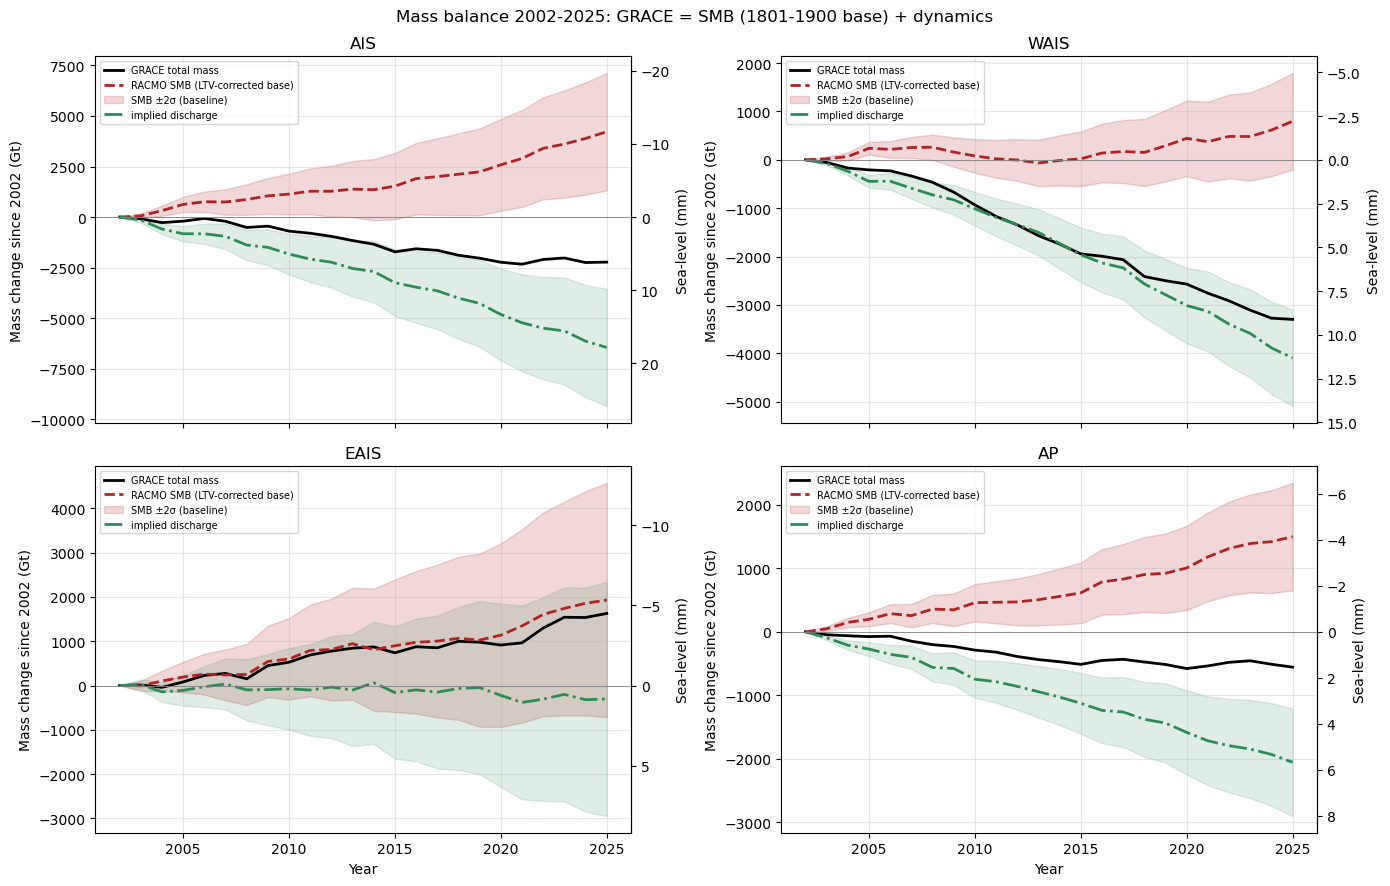

In [80]:
BASELINE = (1801, 1900); GT_PER_MM = 361.8; region_idx = {"AIS":0,"WAIS":1,"EAIS":2,"AP":3}
def combined_smb(r):
    return pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]])
def baseline_error(r):
    k = region_idx[r]; yb = [y for y in range(BASELINE[0], BASELINE[1]+1) if y <= 2000]
    return smb_reg_ens[[y-1801 for y in yb], :, k].mean(axis=0).std(ddof=1) if yb else 0.0
yrs = np.arange(2002, 2026)
zeroed = lambda s: s.reindex(yrs) - s.reindex(yrs).loc[2002]
def trend(s):
    y = s.reindex(yrs).values; x = yrs.astype(float); v = np.isfinite(y)
    return np.polyfit(x[v], y[v], 1)[0] if v.sum() > 2 else np.nan
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
print(f"{'Region':<6}{'GRACE':>9}{'SMB':>9}{'dyn':>8}")
for ax, r in zip(axes.ravel(), region_names):
    comb = combined_smb(r); base = comb.loc[BASELINE[0]:BASELINE[1]].mean(); sig_base = 2*baseline_error(r)
    g = zeroed(grace_annual(grace_masks[r])); c = zeroed((comb-base).loc[2002:2025].cumsum()); dyn = g - c
    c_err = np.arange(len(yrs))*sig_base
    ax.plot(yrs, g.values, color="black", lw=2, label="GRACE total mass")
    ax.plot(yrs, c.values, color="firebrick", lw=2, ls="--", label="RACMO SMB (LTV-corrected base)")
    ax.fill_between(yrs, c.values-c_err, c.values+c_err, color="firebrick", alpha=0.18, label="SMB ±2σ (baseline)")
    ax.plot(yrs, dyn.values, color="seagreen", lw=2, ls="-.", label="implied discharge")
    ax.fill_between(yrs, dyn.values-c_err, dyn.values+c_err, color="seagreen", alpha=0.15)
    ax.axhline(0, color="gray", lw=0.6); ax.set_title(r); ax.set_ylabel("Mass change since 2002 (Gt)")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    ax.secondary_yaxis("right", functions=(lambda m: -m/GT_PER_MM, lambda s: -s*GT_PER_MM)).set_ylabel("Sea-level (mm)")
    print(f"{r:<6}{trend(g):>9.1f}{trend(c):>9.1f}{trend(dyn):>8.1f}")
for ax in axes[-1, :]: ax.set_xlabel("Year")
fig.suptitle(f"Mass balance 2002-2025: GRACE = SMB ({BASELINE[0]}-{BASELINE[1]} base) + dynamics", fontsize=12)
fig.tight_layout(); plt.show()


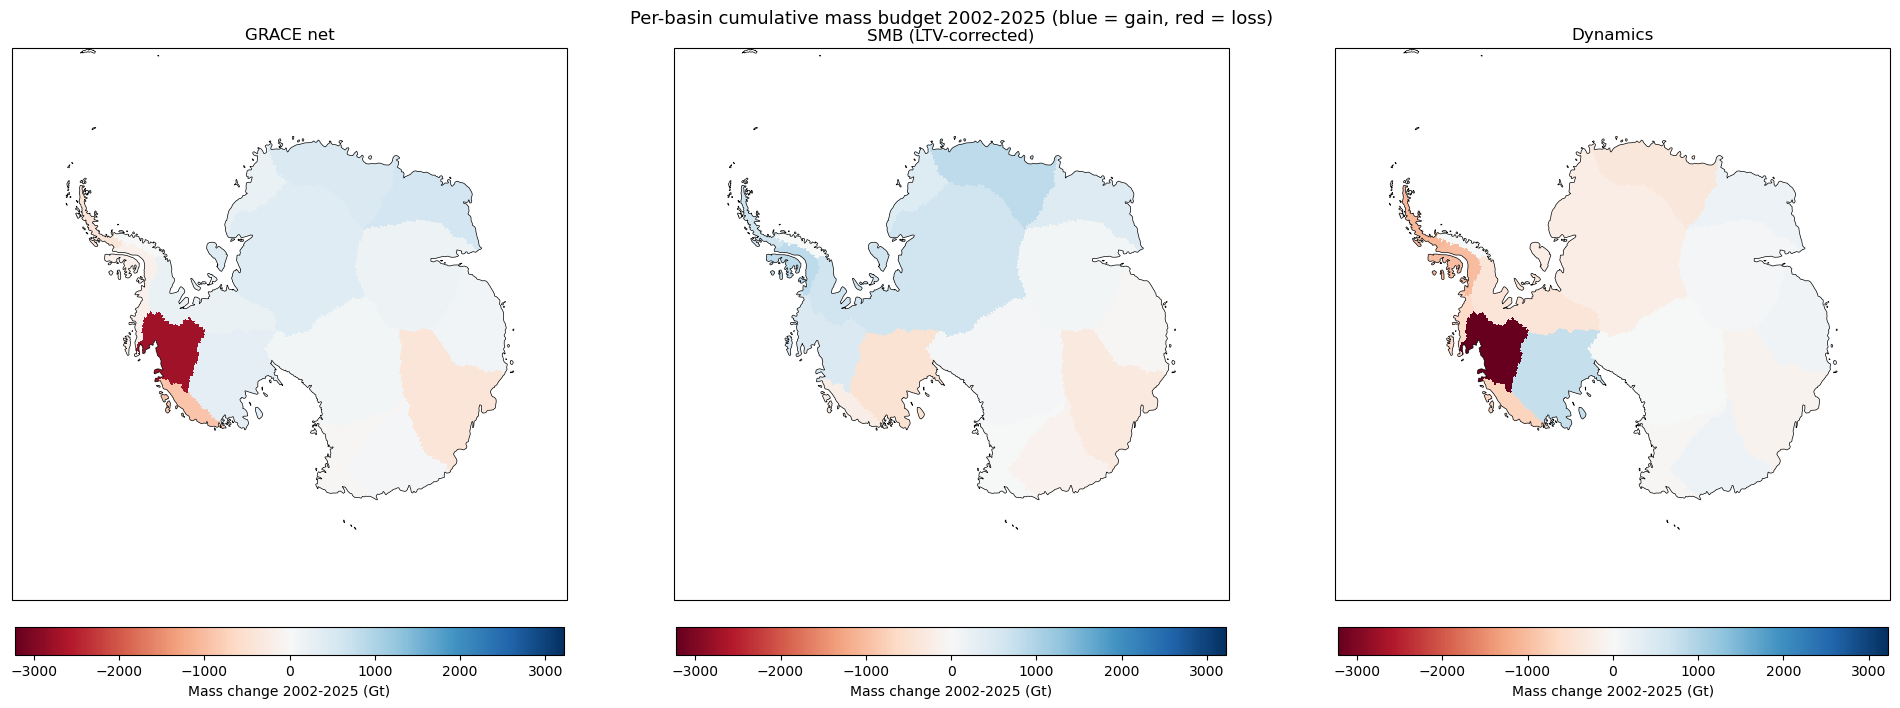

In [23]:
y0, y1 = 2002, 2025; dM_grace, dM_smb, dM_dyn = {}, {}, {}
for bid in basin_ids_unique:
    gmask = near_basin == bid
    if gmask.sum() == 0: dM_grace[bid] = np.nan
    else:
        m = np.array([np.nansum(np.where(gmask, ewh[t]*gcell*10/1e12, 0)) for t in range(ewh.shape[0])])
        gm = pd.Series(m, index=gyear).groupby(level=0).mean(); dM_grace[bid] = gm.get(y1, np.nan) - gm.get(y0, np.nan)
    rmask = basin_mask == bid
    smb = pd.Series([np.nansum(np.where(rmask, smb_ann.values[t]*cell_area_m2, 0))/1e12 for t in range(len(years_obs))], index=years_obs)
    comb = pd.concat([smb_basin_recon[bid].loc[:1978], smb.loc[1979:]]); base = comb.loc[1801:1900].mean()
    dM_smb[bid] = (smb.loc[y0:y1] - base).sum(); dM_dyn[bid] = dM_grace[bid] - dM_smb[bid]
def paint(dct):
    f = np.full(basin_mask.shape, np.nan)
    for bid, v in dct.items(): f[basin_mask == bid] = v
    return f
vmax = np.nanmax(np.abs(list(dM_grace.values())+list(dM_smb.values())+list(dM_dyn.values())))
fig, axes = plt.subplots(1, 3, figsize=(20, 7.5), subplot_kw={"projection": ccrs.SouthPolarStereo()})
for ax, (title, dct) in zip(axes, [("GRACE net", dM_grace), ("SMB (LTV-corrected)", dM_smb), ("Dynamics", dM_dyn)]):
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = ax.pcolormesh(lon_racmo, lat_racmo, paint(dct), transform=ccrs.PlateCarree(), vmin=-vmax, vmax=vmax, cmap="RdBu", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2); ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.set_title(title, fontsize=12, pad=6)
    fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.04, shrink=0.85).set_label("Mass change 2002-2025 (Gt)")
fig.suptitle("Per-basin cumulative mass budget 2002-2025 (blue = gain, red = loss)", fontsize=13)
plt.tight_layout(); plt.show()


/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_65399/3372000879.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.07, 1, 0.96]); plt.show()


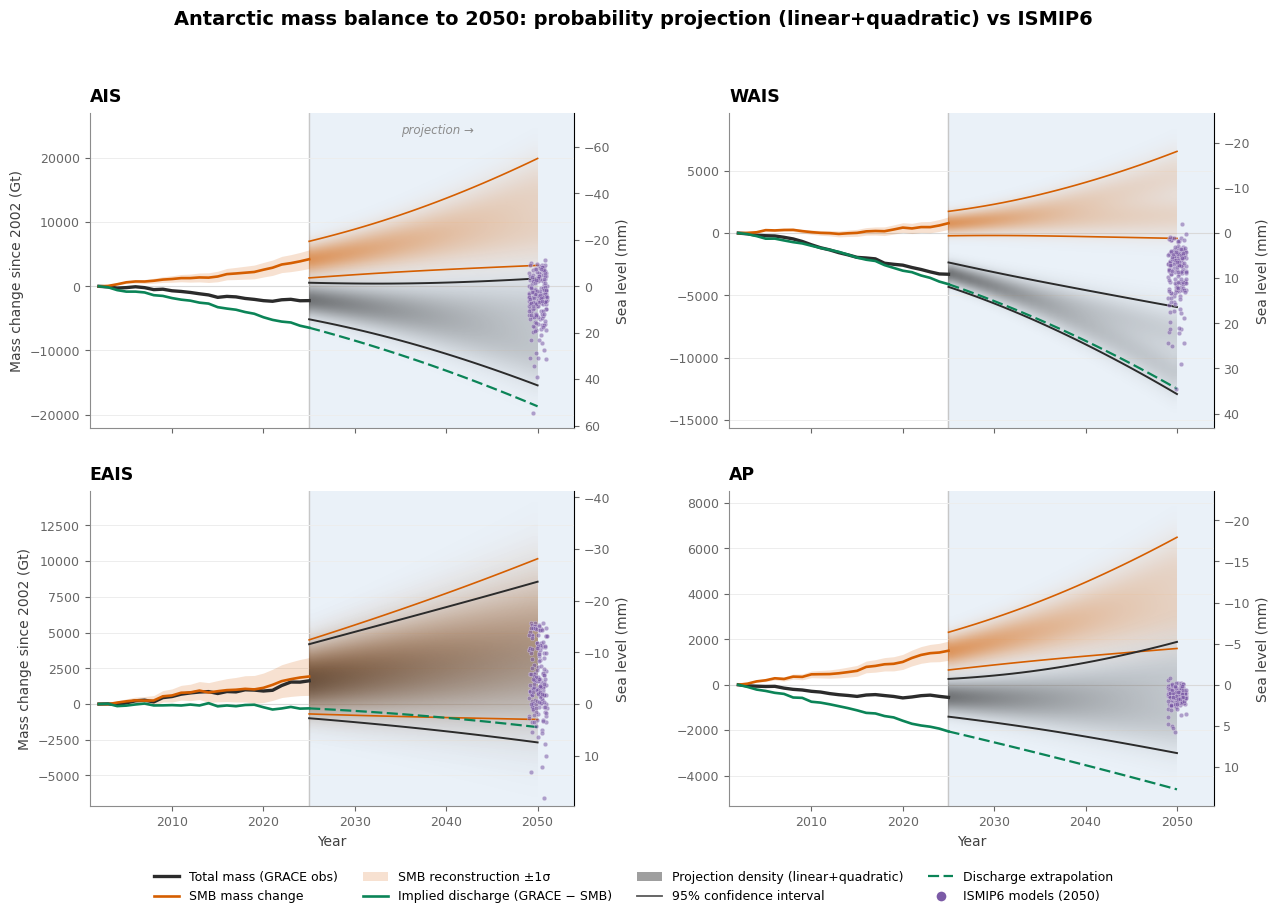

In [41]:
# ===== Antarctic mass balance to 2050 — probability heatmap + solid 95% CI edges =====
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from scipy.stats import norm

TARGET_YEAR = 2050
region_idx = {"AIS":0,"WAIS":1,"EAIS":2,"AP":3}
C_TOT, C_SMB, C_DIS, C_IS = "#2b2b2b", "#D55E00", "#0B8457", "#7B5AA6"
C_PROJ = "#eaf1f8"
def baseline_mean(r):
    return pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]]).loc[1801:1900].mean()
def baseline_error(r):
    k = region_idx[r]; ib = [y-1801 for y in range(1801, 1901)]
    return smb_reg_ens[ib, :, k].mean(0).std(ddof=1)
def fit_extrap(t_h, y_h, t_f, deg, t_a, y_a):
    Xh = np.vander(t_h, deg+1); beta, *_ = np.linalg.lstsq(Xh, y_h, rcond=None)
    resid = y_h - Xh @ beta; dof = max(len(t_h)-(deg+1), 1); s2 = (resid @ resid)/dof
    cov = s2 * np.linalg.inv(Xh.T @ Xh)
    D = np.vander(t_f, deg+1) - np.vander([t_a], deg+1)
    return D @ beta + y_a, np.sqrt(np.maximum(np.einsum('ij,jk,ik->i', D, cov, D), 0))
def _mix_density(ygrid, comps):
    dens = np.zeros((len(ygrid), comps[0][0].shape[0]))
    for mu, sig in comps:
        dens += norm.pdf(ygrid[:, None], mu[None, :], np.maximum(sig, 1e-6)[None, :])
    return dens / len(comps)                             # equal credence across hypotheses
def prob_fan(ax, xs, ygrid, comps, color, amax=0.62, gamma=0.8, z=2):
    a = np.clip(_mix_density(ygrid, comps) / _mix_density(ygrid, comps).max(), 0, 1) ** gamma
    rgba = np.empty((len(ygrid), len(xs), 4)); rgba[..., :3] = mcolors.to_rgb(color); rgba[..., 3] = a * amax
    ax.imshow(rgba, extent=[xs[0], xs[-1], ygrid[0], ygrid[-1]], origin="lower",
              aspect="auto", interpolation="bilinear", zorder=z)
def fan_ci(ygrid, comps, q=(0.025, 0.975)):
    cdf = np.cumsum(_mix_density(ygrid, comps), axis=0); cdf /= cdf[-1][None, :]
    lo = np.array([np.interp(q[0], cdf[:, j], ygrid) for j in range(cdf.shape[1])])
    hi = np.array([np.interp(q[1], cdf[:, j], ygrid) for j in range(cdf.shape[1])])
    return lo, hi

ismip = pd.read_csv(os.path.expanduser("~/DataFiles/ISMIP6/ismip6_2050_mass_Gt.csv"))
_jit = np.random.default_rng(0)
hist = np.arange(2002, 2026); fut = np.arange(2025, TARGET_YEAR+1)
th = (hist-2002).astype(float); tfa = (fut-2002).astype(float)
DASH = (0, (5, 2))

fig, axes = plt.subplots(2, 2, figsize=(14.5, 9), sharex=True, gridspec_kw={"wspace": 0.32})
for i, (ax, r) in enumerate(zip(axes.ravel(), region_names)):
    B = baseline_mean(r); sig_base = baseline_error(r)
    g = grace_annual(grace_masks[r]).reindex(hist); black = (g - g.loc[2002]).values
    rc = (raw_series[r] - B).loc[2002:2025].cumsum(); red = (rc - rc.loc[2002]).reindex(hist).values
    green = black - red
    base_h = sig_base*(hist-2002); base_f = sig_base*(fut-2002)
    rl, sl = fit_extrap(th, red, tfa, 1, th[-1], red[-1])
    rq, sq = fit_extrap(th, red, tfa, 2, th[-1], red[-1])
    sl_t, sq_t = np.hypot(sl, base_f), np.hypot(sq, base_f)
    ge, _ = fit_extrap(th, green, tfa, 2, th[-1], green[-1])
    smb_comps = [(rl, sl_t), (rq, sq_t)]
    tot_comps = [(rl+ge, sl_t), (rq+ge, sq_t)]

    lo = np.min([black.min(), red.min()-base_h.max(), green.min(), (rl-3*sl_t).min(), (rq-3*sq_t).min(),
                 ge.min(), (ge+rl-3*sl_t).min(), (ge+rq-3*sq_t).min()])
    hi = np.max([black.max(), red.max()+base_h.max(), green.max(), (rl+3*sl_t).max(), (rq+3*sq_t).max(),
                 (ge+rl+3*sl_t).max(), (ge+rq+3*sq_t).max()])
    pad = 0.06*(hi-lo); ylim = (lo-pad, hi+pad); ygrid = np.linspace(*ylim, 400)

    ax.axvspan(2025, 2054, color=C_PROJ, zorder=0)
    ax.axvline(2025, color="0.78", lw=1.0, zorder=0.5)
    ax.axhline(0, color="0.85", lw=0.8, zorder=1)
    prob_fan(ax, fut, ygrid, smb_comps, C_SMB, z=2)
    prob_fan(ax, fut, ygrid, tot_comps, C_TOT, z=3)
    # solid 95% CI edges
    s_lo, s_hi = fan_ci(ygrid, smb_comps); t_lo, t_hi = fan_ci(ygrid, tot_comps)
    ax.plot(fut, s_lo, color=C_SMB, lw=1.2, zorder=4); ax.plot(fut, s_hi, color=C_SMB, lw=1.2, zorder=4)
    ax.plot(fut, t_lo, color=C_TOT, lw=1.4, zorder=4); ax.plot(fut, t_hi, color=C_TOT, lw=1.4, zorder=4)
    ax.plot(fut, ge, color=C_DIS, lw=1.6, ls=DASH, zorder=4)
    ax.fill_between(hist, red-base_h, red+base_h, color=C_SMB, alpha=0.18, lw=0, zorder=2)
    ax.plot(hist, black, color=C_TOT, lw=2.4, zorder=6)
    ax.plot(hist, red,   color=C_SMB, lw=1.9, zorder=6)
    ax.plot(hist, green, color=C_DIS, lw=1.9, zorder=6)
    gser = grace_annual(grace_masks[r]); g2015 = gser.loc[2015] - gser.loc[2002]
    vals = g2015 + ismip[r].values
    ax.scatter(2050 + _jit.uniform(-1.0, 1.0, len(vals)), vals, s=11, color=C_IS,
               alpha=0.55, edgecolor="white", linewidth=0.3, zorder=5)

    ax.set_ylim(*ylim); ax.set_xlim(2001, 2054)
    ax.set_title(r, fontweight="bold", fontsize=12.5, loc="left", pad=8)
    ax.grid(axis="y", color="0.93", lw=0.7); ax.set_axisbelow(True)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"): ax.spines[sp].set_color("0.55")
    ax.tick_params(labelsize=9, colors="0.4")
    if i % 2 == 0:
        ax.set_ylabel("Mass change since 2002 (Gt)", fontsize=10, color="0.25")
    sec = ax.secondary_yaxis("right", functions=(lambda m:-m/GT_PER_MM, lambda s:-s*GT_PER_MM))
    sec.set_ylabel("Sea level (mm)", fontsize=10, color="0.25")
    sec.tick_params(labelsize=9, colors="0.4"); sec.spines["top"].set_visible(False)
for ax in axes[-1, :]: ax.set_xlabel("Year", fontsize=10, color="0.25")
axes[0,0].text(2039, axes[0,0].get_ylim()[1]*0.94, "projection →", fontsize=8.5, color="0.55", style="italic", ha="center", va="top")

handles = [
    Line2D([0],[0], color=C_TOT, lw=2.4, label="Total mass (GRACE obs)"),
    Line2D([0],[0], color=C_SMB, lw=1.9, label="SMB mass change"),
    Patch(facecolor=C_SMB, alpha=0.18, label="SMB reconstruction ±1σ"),
    Line2D([0],[0], color=C_DIS, lw=1.9, label="Implied discharge (GRACE − SMB)"),
    Patch(facecolor=C_TOT, alpha=0.45, label="Projection density (linear+quadratic)"),
    Line2D([0],[0], color="0.35", lw=1.3, label="95% confidence interval"),
    Line2D([0],[0], color=C_DIS, lw=1.6, ls=DASH, label="Discharge extrapolation"),
    Line2D([0],[0], marker="o", color="none", markerfacecolor=C_IS, markeredgecolor="white", markersize=8, label="ISMIP6 models (2050)"),
]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Antarctic mass balance to 2050: probability projection (linear+quadratic) vs ISMIP6",
             fontsize=14, fontweight="bold", y=0.995)
fig.tight_layout(rect=[0, 0.07, 1, 0.96]); plt.show()


reg    kappa accel(Gt/yr²)  p_accel  meanAnom(Gt/yr)  p_incr
AIS     0.00          8.08    0.008            184.1   0.000
WAIS    0.00          3.27    0.194             36.8   0.029
EAIS    0.00          2.43    0.362             84.8   0.000
AP      0.63          2.39    0.132             62.5   0.000


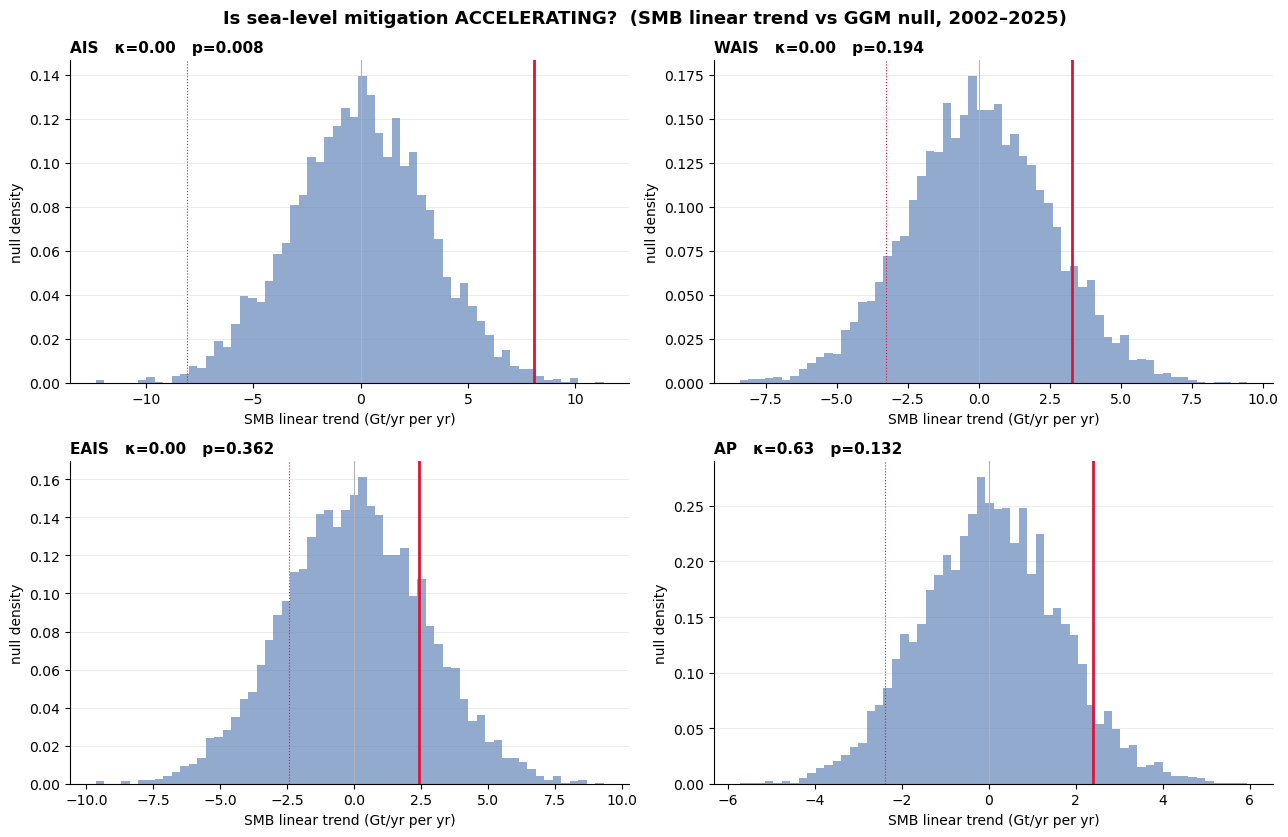

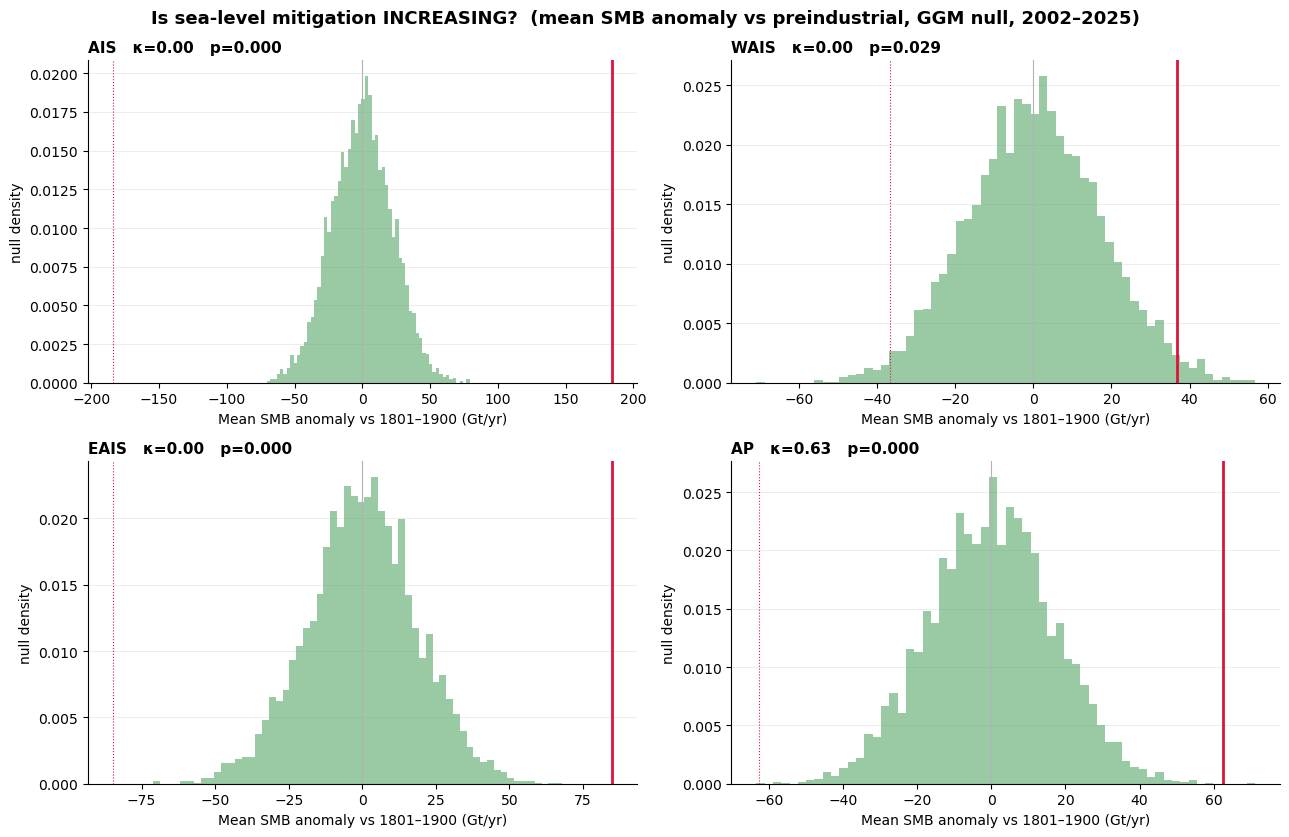

In [44]:
# ===== Two tests on sea-level mitigation: acceleration vs mere increase (GGM null only, 2002–2025) =====
from numpy.random import default_rng
rng = default_rng(0)
YR0, YR1 = 2002, 2025
N = YR1 - YR0 + 1; x = np.arange(N, dtype=float); N_SURR = 5000
lintrend = lambda v: np.polyfit(x, v, 1)[0]
def baseline_mean(r):
    return pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]]).loc[1801:1900].mean()

fig_a, axes_a = plt.subplots(2, 2, figsize=(13, 8.5))    # acceleration (SMB trend → SLM curvature)
fig_b, axes_b = plt.subplots(2, 2, figsize=(13, 8.5))    # increase   (mean anomaly → SLM slope)
print(f"{'reg':<5}{'kappa':>7}{'accel(Gt/yr²)':>14}{'p_accel':>9}{'meanAnom(Gt/yr)':>17}{'p_incr':>8}")
for aa, ab, r in zip(axes_a.ravel(), axes_b.ravel(), region_names):
    smb = raw_series[r].loc[YR0:YR1].values.astype(float)
    B = baseline_mean(r)
    obs_trend = lintrend(smb)                            # acceleration of SLM
    obs_mean  = smb.mean() - B                           # slope of SLM = mean SMB anomaly vs preindustrial

    fit = ggm_fits[r]
    acf = _ggm_acf(fit["kappa"], fit["phi"], N) * fit["sigma_w"]**2
    L = np.linalg.cholesky(_toeplitz(acf))
    surr = L @ rng.standard_normal((N, N_SURR))          # zero-mean GGM surrogates, shared by both tests
    null_trend = np.polyfit(x, surr, 1)[0]
    null_mean  = surr.mean(axis=0)
    p_accel = (np.abs(null_trend) >= abs(obs_trend)).mean()
    p_incr  = (np.abs(null_mean)  >= abs(obs_mean)).mean()

    aa.hist(null_trend, bins=60, density=True, color="#4C72B0", alpha=0.6)
    aa.axvline(obs_trend, color="crimson", lw=2); aa.axvline(-abs(obs_trend), color="crimson", lw=0.8, ls=":")
    aa.axvline(0, color="0.7", lw=0.8)
    aa.set_title(f"{r}   κ={fit['kappa']:.2f}   p={p_accel:.3f}", fontsize=11, fontweight="bold", loc="left")
    aa.set_xlabel("SMB linear trend (Gt/yr per yr)"); aa.set_ylabel("null density")
    for sp in ("top","right"): aa.spines[sp].set_visible(False)
    aa.grid(axis="y", color="0.93", lw=0.7); aa.set_axisbelow(True)

    ab.hist(null_mean, bins=60, density=True, color="#55A868", alpha=0.6)
    ab.axvline(obs_mean, color="crimson", lw=2); ab.axvline(-abs(obs_mean), color="crimson", lw=0.8, ls=":")
    ab.axvline(0, color="0.7", lw=0.8)
    ab.set_title(f"{r}   κ={fit['kappa']:.2f}   p={p_incr:.3f}", fontsize=11, fontweight="bold", loc="left")
    ab.set_xlabel("Mean SMB anomaly vs 1801–1900 (Gt/yr)"); ab.set_ylabel("null density")
    for sp in ("top","right"): ab.spines[sp].set_visible(False)
    ab.grid(axis="y", color="0.93", lw=0.7); ab.set_axisbelow(True)

    print(f"{r:<5}{fit['kappa']:>7.2f}{obs_trend:>14.2f}{p_accel:>9.3f}{obs_mean:>17.1f}{p_incr:>8.3f}")

fig_a.suptitle("Is sea-level mitigation ACCELERATING?  (SMB linear trend vs GGM null, 2002–2025)",
               fontsize=13, fontweight="bold")
fig_b.suptitle("Is sea-level mitigation INCREASING?  (mean SMB anomaly vs preindustrial, GGM null, 2002–2025)",
               fontsize=13, fontweight="bold")
fig_a.tight_layout(); fig_b.tight_layout(); plt.show()



reg   kappa    ToE
AIS    0.00   2004
WAIS   0.00   None
EAIS   0.00   2021
AP     0.63   None


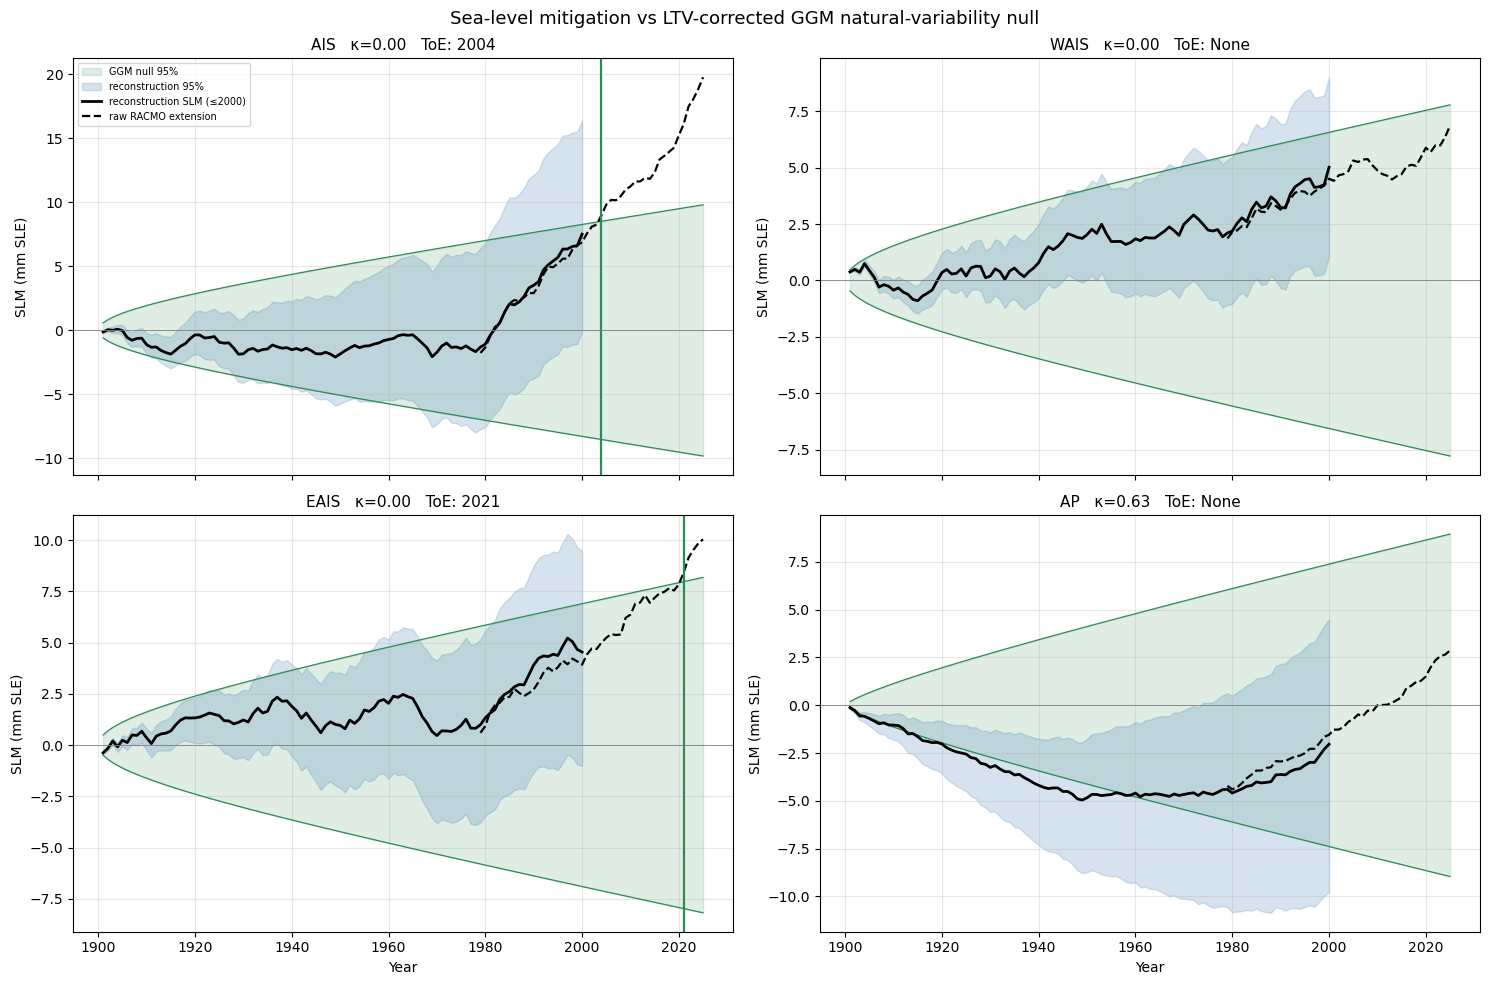

In [27]:
from scipy.stats import norm
GT, NB, NA = 361.8, 100, 125
def slm_sigma(fit):
    R = _toeplitz(_ggm_acf(fit["kappa"], fit["phi"], NB+NA) * fit["sigma_w"]**2)
    return np.array([np.sqrt((a := np.concatenate([np.full(NB,-n/NB),np.ones(n)])) @ R[:NB+n,:NB+n] @ a)/GT
                     for n in range(1, NA+1)])
def emergence(traj, sig, yy):
    out = traj > 1.96*sig
    for i in range(len(yy)):
        if out[i:].all(): return int(yy[i])
    return None
years, cent, yr_obs = np.arange(1901, 2026), np.arange(1901, 2001), np.arange(1979, 2026)
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
print(f"{'reg':4s}{'kappa':>7s}{'ToE':>7s}")
for ax, (k, r) in zip(axes.ravel(), enumerate(region_names)):
    recon_ts = np.asarray(recon_series[r]); slm_recon = sea_level_mitigation(recon_ts)
    ens = smb_reg_ens[:, :, k]
    slm_mem = np.stack([sea_level_mitigation(ens[:, m]) for m in range(ens.shape[1])])
    lo, hi = np.percentile(slm_mem, [2.5, 97.5], axis=0)
    slm_ext = extend_slm(recon_ts, raw_series[r].loc[1979:2025].values)
    sig = slm_sigma(ggm_fits[r])
    toe = emergence(np.concatenate([slm_recon[100:178], slm_ext]), sig, years)
    ax.fill_between(years, -1.96*sig, 1.96*sig, color="seagreen", alpha=0.15, label="GGM null 95%")
    ax.plot(years, 1.96*sig, color="seagreen", lw=0.9); ax.plot(years, -1.96*sig, color="seagreen", lw=0.9)
    ax.fill_between(cent, lo[100:200], hi[100:200], color="steelblue", alpha=0.22, label="reconstruction 95%")
    ax.plot(cent, slm_recon[100:200], color="k", lw=2, label="reconstruction SLM (≤2000)")
    ax.plot(yr_obs, slm_ext, color="k", lw=1.6, ls="--", label="raw RACMO extension")
    if toe: ax.axvline(toe, color="seagreen", lw=1.6)
    ax.axhline(0, color="gray", lw=0.6)
    ax.set_title(f"{r}   κ={ggm_fits[r]['kappa']:.2f}   ToE: {toe}", fontsize=11)
    ax.set_ylabel("SLM (mm SLE)"); ax.grid(alpha=0.3)
    if k == 0: ax.legend(fontsize=7)
    print(f"{r:4s}{ggm_fits[r]['kappa']:7.2f}{str(toe):>7s}")
for ax in axes[-1, :]: ax.set_xlabel("Year")
fig.suptitle("Sea-level mitigation vs LTV-corrected GGM natural-variability null", fontsize=13)
fig.tight_layout(); plt.show()


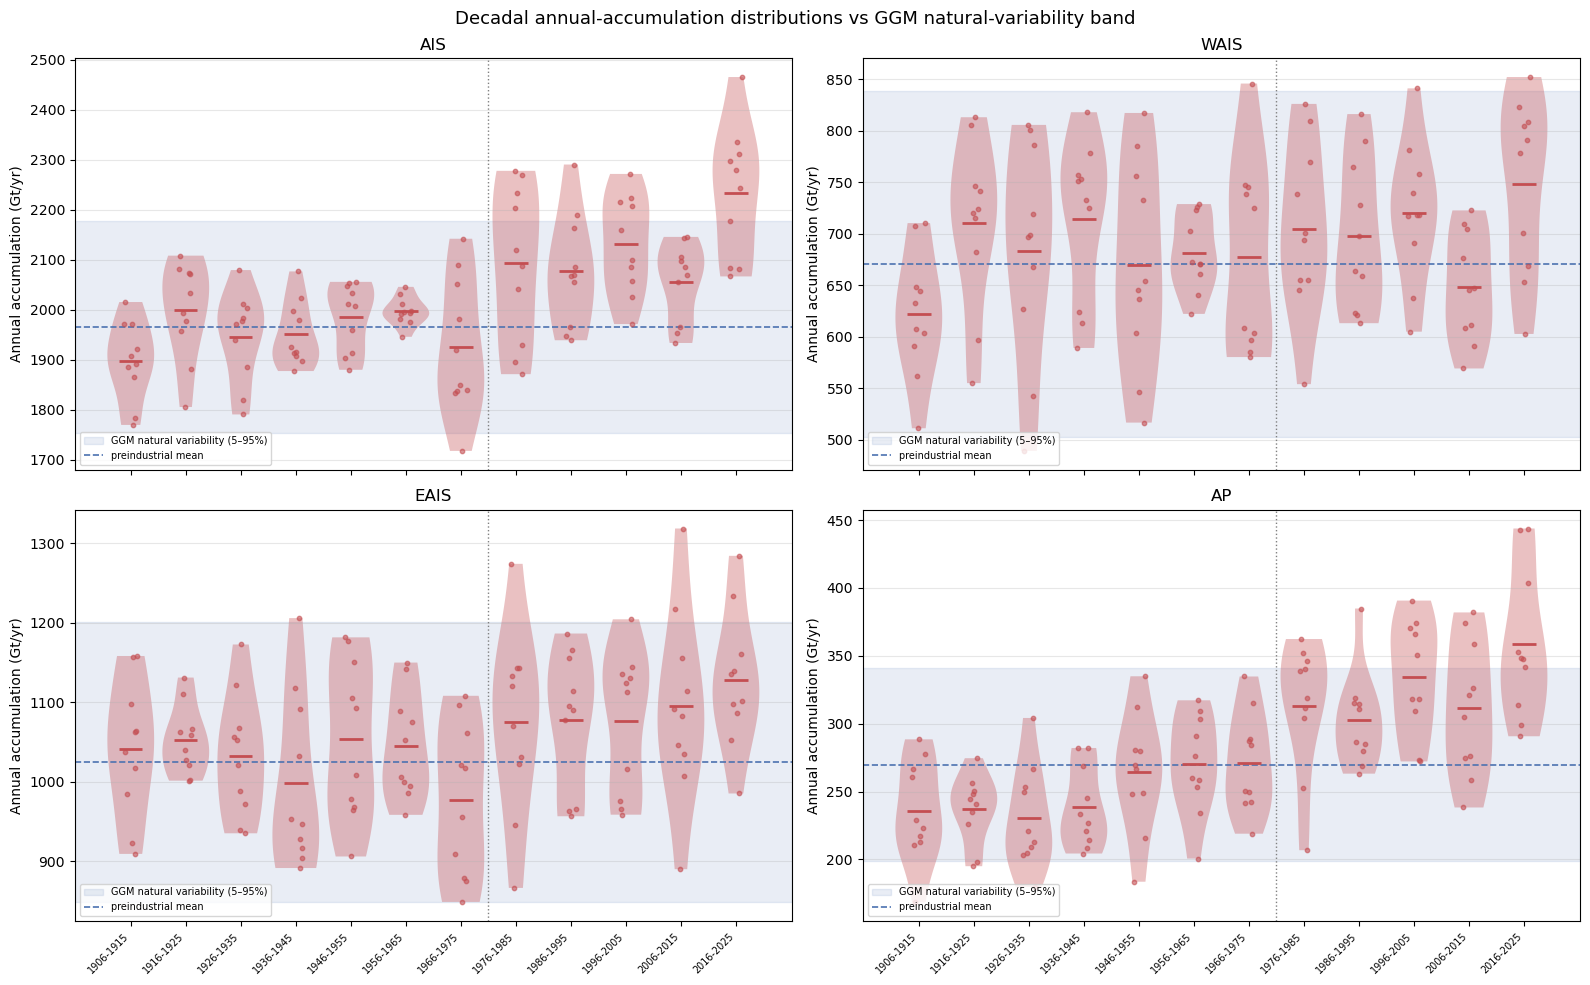

In [28]:
rng = np.random.default_rng(0); NULL_C, OBS_C = "#4C72B0", "#C44E52"
def combined(r):
    return pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]])
starts = list(range(1906, 2017, 10)); decades = [(s, s+9) for s in starts]; labels = [f"{s}-{s+9}" for s in starts]
split_x = next(i for i, (a, b) in enumerate(decades) if b >= 1979) - 0.5
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
for ax, r in zip(axes.ravel(), region_names):
    comb = combined(r); base = comb.loc[1801:1900].mean(); fit = ggm_fits[r]
    sd = np.sqrt(_ggm_acf(fit["kappa"], fit["phi"], 1)[0] * fit["sigma_w"]**2)
    ax.axhspan(base-1.96*sd, base+1.96*sd, color=NULL_C, alpha=0.12, label="GGM natural variability (5–95%)")
    ax.axhline(base, color=NULL_C, ls="--", lw=1.2, label="preindustrial mean"); ax.axvline(split_x, color="0.5", ls=":", lw=1.0)
    data = [comb.loc[a:b].values for (a, b) in decades]; xpos = np.arange(len(decades))
    vp = ax.violinplot(data, positions=xpos, widths=0.85, showmeans=True, showextrema=False)
    for body in vp["bodies"]: body.set_facecolor(OBS_C); body.set_alpha(0.35)
    vp["cmeans"].set_color(OBS_C); vp["cmeans"].set_linewidth(2)
    for i, v in enumerate(data): ax.scatter(i + rng.uniform(-0.12, 0.12, len(v)), v, s=10, color=OBS_C, alpha=0.6, zorder=3)
    ax.set_title(r); ax.set_ylabel("Annual accumulation (Gt/yr)")
    ax.set_xticks(xpos); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.legend(fontsize=7, loc="lower left"); ax.grid(axis="y", alpha=0.3)
fig.suptitle("Decadal annual-accumulation distributions vs GGM natural-variability band", fontsize=13)
fig.tight_layout(); plt.show()


In [29]:
import urllib.request
sam_path = os.path.expanduser("~/DataFiles/marshall_sam.txt")
if not os.path.exists(sam_path):
    urllib.request.urlretrieve("http://www.nerc-bas.ac.uk/public/icd/gjma/newsam.1957.2007.txt", sam_path)
_raw = pd.read_csv(sam_path, sep=r"\s+", header=0, index_col=0)
sam = _raw.apply(pd.to_numeric, errors="coerce").dropna().mean(axis=1)
sam.index = sam.index.astype(int)
print("Marshall SAM:", int(sam.index.min()), "-", int(sam.index.max()), " n =", len(sam))
def detrend_cols(A):
    t = np.arange(A.shape[0], dtype=float); tc = t - t.mean()
    return A - A.mean(0) - tc[:, None] * ((tc[:, None]*A).sum(0)/(tc@tc))[None, :]
def trend_cols(A):
    t = np.arange(A.shape[0], dtype=float); tc = t - t.mean()
    return (tc[:, None] * A).sum(0) / (tc @ tc)


Marshall SAM: 1957 - 2025  n = 69


In [30]:
brom_path = os.path.expanduser("~/DataFiles/bromwich_recon_t2m_1958-2025.nc")
if not os.path.exists(brom_path):
    urllib.request.urlretrieve("https://amrdcdata.ssec.wisc.edu/dataset/16c76c35-5cf7-4001-9adc-b7b36a9ac94c/"
        "resource/29e548a9-2405-4aef-9d1e-387ab8489a12/download/recon_t2m_1958-2025_ano.final.nc", brom_path)
brom = xr.open_dataset(brom_path); bann = brom["RECON"].groupby("time.year").mean("time")
def brom_trend(y0, y1):
    sub = bann.sel(year=slice(y0, y1)).values.reshape(y1-y0+1, -1)
    tc = np.arange(sub.shape[0], dtype=float); tc -= tc.mean()
    return (tc[:, None]*sub).sum(0) / (tc @ tc) * 10
blat, blon = brom["lat"].values.ravel(), brom["lon"].values.ravel()
_, ii = cKDTree(to_xyz(blat, blon)).query(to_xyz(lat_racmo.ravel()[valid_cells], lon_racmo.ravel()[valid_cells]))
print("Bromwich warming 1958-2000 mean:", f"{np.nanmean(brom_trend(1958,2000)):+.3f} K/dec")


Bromwich warming 1958-2000 mean: +0.063 K/dec


In [31]:
def _cols(da, y0, y1, scale=1.0): return da.sel(year=slice(y0,y1)).values.reshape(y1-y0+1,-1)[:, valid_cells]*scale
SAM_HI = int(min(2025, sam.index.max()))
smb_T = detrend_cols(_cols(smb_ann, 1979, 2025, _va/1e12)); t2m_T = detrend_cols(_cols(t2m_ann, 1979, 2025))
Tsens_cell = (t2m_T*smb_T).sum(0) / (t2m_T*t2m_T).sum(0)
smb_S = detrend_cols(_cols(smb_ann, 1979, SAM_HI, _va/1e12))
sam_s = sam.reindex(np.arange(1979, SAM_HI+1)).values
sam_sd = sam_s - np.polyval(np.polyfit(np.arange(len(sam_s)), sam_s, 1), np.arange(len(sam_s)))
SAMsens_cell = (sam_sd[:,None]*smb_S).sum(0) / (sam_sd@sam_sd)
sl = slice(1957-1801, 2000-1801+1)
smb_tr = trend_cols(racmo_smb_recon.reshape(200,-1)[sl][:, valid_cells] * _va/1e12) * 10
sam_tr = np.polyfit(np.arange(44), sam.loc[1957:2000].values, 1)[0] * 10
brom_Ttr_cells = brom_trend(1958, 2000)[ii]
print("M&T observed warming (°C/dec): AIS 0.04-0.10, WAIS 0.06-0.20, EAIS 0.01-0.11, AP 0.11-0.39")
print(f"{'reg':4s} {'Tsens':>7s} {'SAMsens':>8s} | {'total':>6s} {'SAMcong':>8s} {'resid':>7s} {'reqTtr':>7s} {'actTtr(Brom)':>13s}")
for r in region_names:
    mk = _regions[r]
    total = smb_tr[mk].sum(); sam_cong = (SAMsens_cell[mk]*sam_tr).sum(); resid = total - sam_cong
    reqT = resid / Tsens_cell[mk].sum(); actT = np.average(brom_Ttr_cells[mk], weights=_va[mk])
    print(f"{r:4s} {Tsens_cell[mk].sum():7.1f} {SAMsens_cell[mk].sum():8.1f} | {total:6.1f} {sam_cong:8.1f} {resid:7.1f} {reqT:7.3f} {actT:13.3f}")


M&T observed warming (°C/dec): AIS 0.04-0.10, WAIS 0.06-0.20, EAIS 0.01-0.11, AP 0.11-0.39
reg    Tsens  SAMsens |  total  SAMcong   resid  reqTtr  actTtr(Brom)
AIS    306.8     26.1 |   47.4      5.9    41.5   0.135           nan
WAIS    99.4    -26.8 |   12.8     -6.1    18.9   0.190         0.216
EAIS   166.3      1.7 |   15.4      0.4    15.1   0.091           nan
AP      41.2     51.1 |   19.1     11.6     7.5   0.183         0.304


SAM-congruent explains  68.3% of spatial variance (r=+0.83)
T-sensitivity explains  48.9% of residual variance (r=+0.70)


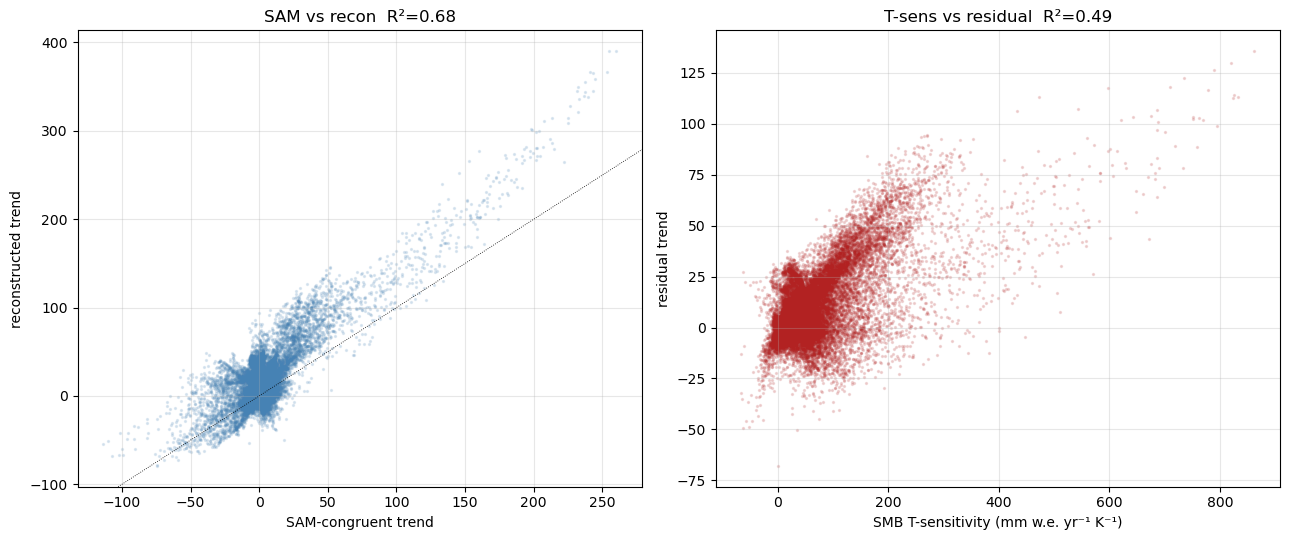

In [32]:
smb_rd = detrend_cols(_cols(smb_ann, 1979, SAM_HI)); smb_rd25 = detrend_cols(_cols(smb_ann, 1979, 2025))
t2m_rd = detrend_cols(_cols(t2m_ann, 1979, 2025))
SAMsens_rate = (sam_sd[:,None]*smb_rd).sum(0) / (sam_sd @ sam_sd)
Tsens_rate   = (t2m_rd*smb_rd25).sum(0) / (t2m_rd*t2m_rd).sum(0)
recon_tr = trend_cols(racmo_smb_recon.reshape(200,-1)[sl][:, valid_cells]) * 10
samcong_tr = SAMsens_rate * sam_tr; resid_tr = recon_tr - samcong_tr
f1 = np.isfinite(recon_tr) & np.isfinite(samcong_tr); r1 = np.corrcoef(recon_tr[f1], samcong_tr[f1])[0,1]
f2 = np.isfinite(resid_tr) & np.isfinite(Tsens_rate); r2 = np.corrcoef(resid_tr[f2], Tsens_rate[f2])[0,1]
print(f"SAM-congruent explains {100*r1**2:5.1f}% of spatial variance (r={r1:+.2f})")
print(f"T-sensitivity explains {100*r2**2:5.1f}% of residual variance (r={r2:+.2f})")
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
ax[0].scatter(samcong_tr[f1], recon_tr[f1], s=2, alpha=0.15, color="steelblue"); ax[0].axline((0,0), slope=1, color="k", lw=0.6, ls=":")
ax[0].set(xlabel="SAM-congruent trend", ylabel="reconstructed trend", title=f"SAM vs recon  R²={r1**2:.2f}")
ax[1].scatter(Tsens_rate[f2], resid_tr[f2], s=2, alpha=0.15, color="firebrick")
ax[1].set(xlabel="SMB T-sensitivity (mm w.e. yr⁻¹ K⁻¹)", ylabel="residual trend", title=f"T-sens vs residual  R²={r2**2:.2f}")
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()


SAM-congruent explains        67.9% (r=+0.82)
Bromwich prediction explains  48.2% of residual variance (r=+0.69)


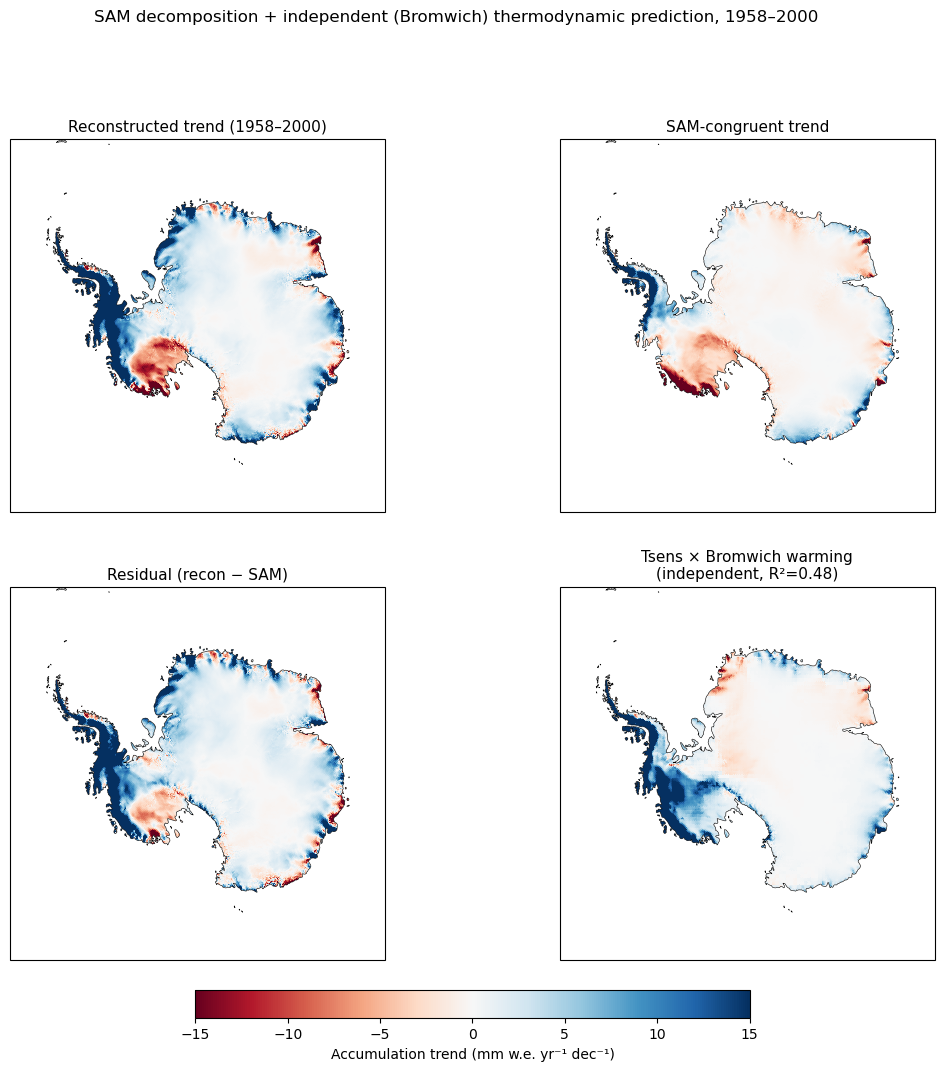

In [33]:
def paint_cells(v): f = np.full(NY*NX, np.nan); f[valid_cells] = v; return f.reshape(NY, NX)
def rc(a, b): m = np.isfinite(a) & np.isfinite(b); return np.corrcoef(a[m], b[m])[0,1]
sl58 = slice(1958-1801, 2000-1801+1)
recon_tr58 = trend_cols(racmo_smb_recon.reshape(200,-1)[sl58][:, valid_cells]) * 10
sam_tr58 = np.polyfit(np.arange(43), sam.loc[1958:2000].values, 1)[0] * 10
samcong58 = SAMsens_rate * sam_tr58; resid58 = recon_tr58 - samcong58
pred_brom = Tsens_rate * brom_trend(1958, 2000)[ii]
r_res, r_sam = rc(resid58, pred_brom), rc(recon_tr58, samcong58)
print(f"SAM-congruent explains       {100*r_sam**2:5.1f}% (r={r_sam:+.2f})")
print(f"Bromwich prediction explains {100*r_res**2:5.1f}% of residual variance (r={r_res:+.2f})")
vlim = 15
panels = [("Reconstructed trend (1958–2000)", recon_tr58), ("SAM-congruent trend", samcong58),
          ("Residual (recon − SAM)", resid58), (f"Tsens × Bromwich warming\n(independent, R²={r_res**2:.2f})", pred_brom)]
fig, axes = plt.subplots(2, 2, figsize=(13, 13), subplot_kw={"projection": ccrs.SouthPolarStereo()})
for ax, (title, field) in zip(axes.ravel(), panels):
    ax.set_extent([-180,180,-90,-60], ccrs.PlateCarree()); ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    im = ax.pcolormesh(lon_racmo, lat_racmo, paint_cells(field), transform=ccrs.PlateCarree(), cmap="RdBu", vmin=-vlim, vmax=vlim, zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2); ax.add_feature(cfeature.COASTLINE, lw=0.4, zorder=3)
    ax.set_title(title, fontsize=11)
cb = fig.colorbar(im, ax=axes, orientation="horizontal", pad=0.03, shrink=0.55); cb.set_label("Accumulation trend (mm w.e. yr⁻¹ dec⁻¹)")
fig.suptitle("SAM decomposition + independent (Bromwich) thermodynamic prediction, 1958–2000", fontsize=12); plt.show()


reg     crossover (median [5–95])
AIS              already net rise
WAIS             already net rise
EAIS                  beyond 2100


/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


AP                    beyond 2100


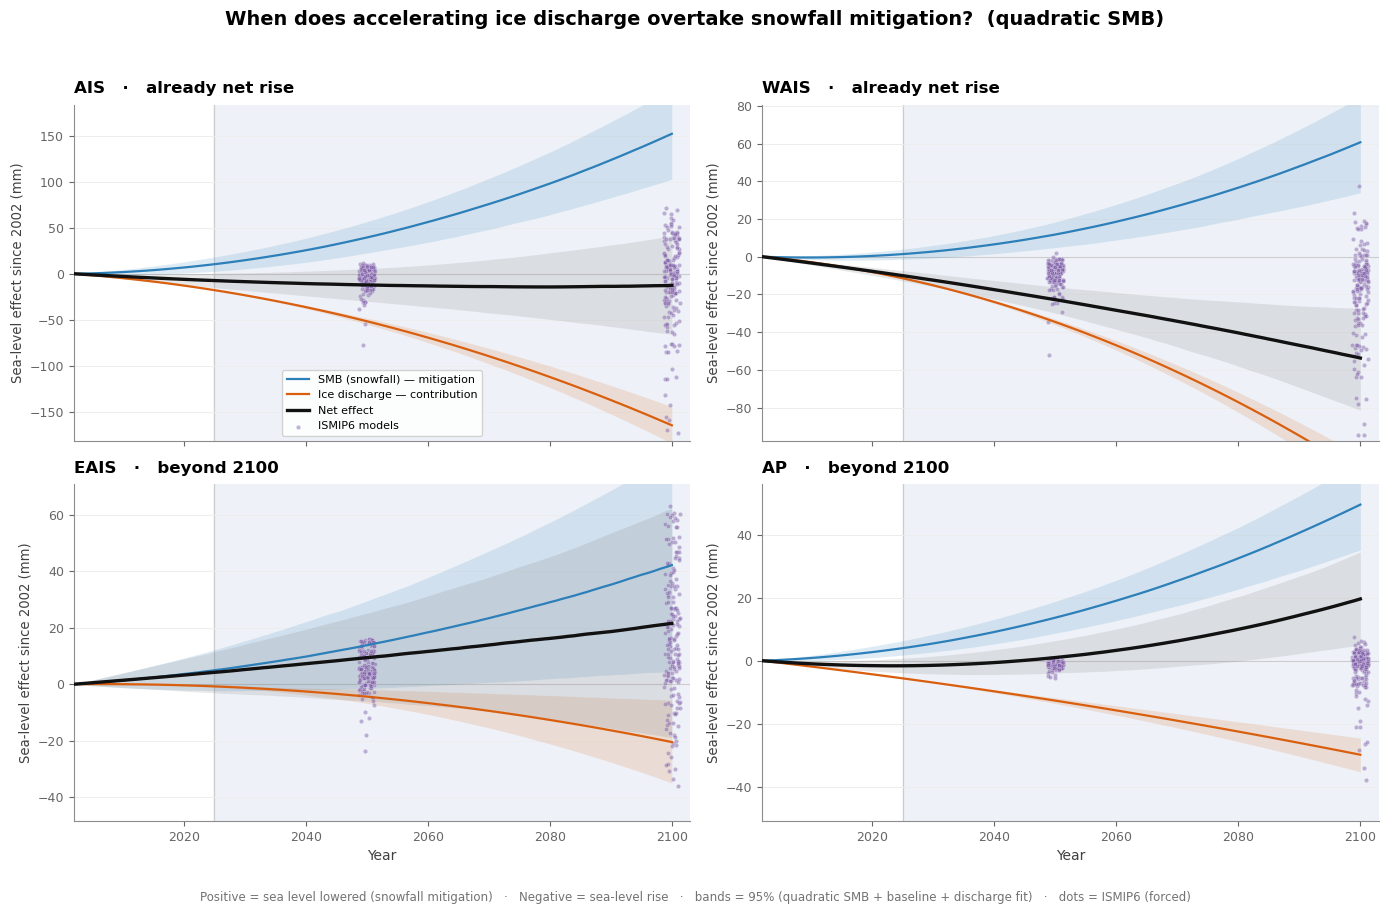

In [72]:
# ===== Mitigation cross-over with Monte-Carlo uncertainty — QUADRATIC SMB (+ discharge fit) =====
from matplotlib.lines import Line2D
GT = GT_PER_MM; TARGET = 2100; N_MC = 4000
region_idx = {"AIS":0,"WAIS":1,"EAIS":2,"AP":3}
C_SMB, C_DIS, C_NET, C_IS = "#2C7FB8", "#D95F0E", "#111111", "#7B5AA6"
def baseline_mean(r):
    return pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]]).loc[1801:1900].mean()
def baseline_error(r):
    k = region_idx[r]; ib = [y-1801 for y in range(1801, 1901)]
    return smb_reg_ens[ib, :, k].mean(0).std(ddof=1)
def polyfit_cov(t, y, deg):                                   # coeffs (high→low power) + covariance
    X = np.vander(t, deg+1); beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta; dof = max(len(t)-(deg+1), 1); s2 = (resid @ resid)/dof
    return beta, s2 * np.linalg.inv(X.T @ X)

ismip = pd.read_csv(os.path.expanduser("~/DataFiles/ISMIP6/ismip6_mass_Gt.csv"))
rng = np.random.default_rng(0); _jit = np.random.default_rng(1)
allyr = np.arange(2002, TARGET+1); T = (allyr-2002).astype(float); idx50 = int(np.searchsorted(allyr, 2050))
hist = np.arange(2002, 2026); th = (hist-2002).astype(float)
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
print(f"{'reg':<5}{'crossover (median [5–95])':>28}")
for i, (ax, r) in enumerate(zip(axes.ravel(), region_names)):
    B = baseline_mean(r); sig_base = baseline_error(r)
    smb = raw_series[r].loc[2002:2025]
    red_obs = (smb - B).cumsum(); red_obs = (red_obs - red_obs.iloc[0]).values
    g = grace_annual(grace_masks[r]).reindex(hist); black = (g - g.loc[2002]).values
    green_obs = black - red_obs
    qc, qcov = polyfit_cov(th, red_obs, 2)                    # SMB quadratic (only)
    gc, gcov = polyfit_cov(th, green_obs, 2)                  # discharge quadratic

    smb_c = rng.multivariate_normal(qc, qcov, N_MC)          # SMB from quadratic fit covariance
    smb_c[:, 1] += rng.normal(0, sig_base, N_MC)             # baseline uncertainty on the rate
    dis_c = rng.multivariate_normal(gc, gcov, N_MC)          # discharge fit covariance
    tot_c = smb_c + dis_c

    mit_s = (smb_c[:,0:1]*T**2 + smb_c[:,1:2]*T + smb_c[:,2:3]) / GT
    dis_s = (dis_c[:,0:1]*T**2 + dis_c[:,1:2]*T + dis_c[:,2:3]) / GT
    mit_s -= mit_s[:, [0]]; dis_s -= dis_s[:, [0]]; net_s = mit_s + dis_s      # anchor to 0 at 2002
    cross = 2002 - tot_c[:,1] / (2*tot_c[:,0])                                 # turning point year, τ=-B/2A
    good = (tot_c[:,0] < 0)
    valid = good & (cross >= 2002) & (cross <= TARGET)
    if valid.mean() > 0.4:
        cm, clo, chi = np.percentile(cross[valid], [50, 5, 95]); cross_txt = f"crossover {cm:.0f} [{clo:.0f}–{chi:.0f}]"
    else:
        cross_txt = "already net rise" if np.median(cross[good]) < 2002 else "beyond 2100"

    P = lambda a, q: np.percentile(a, q, axis=0)
    ax.axvspan(2025, TARGET+3, color="#eef2f8", zorder=0)
    ax.axvline(2025, color="0.8", lw=0.9, zorder=0.5); ax.axhline(0, color="0.8", lw=0.8, zorder=1)
    ax.fill_between(allyr, P(mit_s,2.5), P(mit_s,97.5), color=C_SMB, alpha=0.15, lw=0, zorder=2)
    ax.fill_between(allyr, P(dis_s,2.5), P(dis_s,97.5), color=C_DIS, alpha=0.15, lw=0, zorder=2)
    ax.fill_between(allyr, P(net_s,2.5), P(net_s,97.5), color="0.5", alpha=0.18, lw=0, zorder=2)
    ax.plot(allyr, P(mit_s,50), color=C_SMB, lw=1.6, zorder=4, label="SMB (snowfall) — mitigation")
    ax.plot(allyr, P(dis_s,50), color=C_DIS, lw=1.6, zorder=4, label="Ice discharge — contribution")
    ax.plot(allyr, P(net_s,50), color=C_NET, lw=2.4, zorder=5, label="Net effect")

    gser = grace_annual(grace_masks[r]); g2016 = gser.loc[2016] - gser.loc[2002]
    for yr in (2050, 2100):
        v = (g2016 + ismip[f"{r}_{yr}"].values) / GT
        lbl = "ISMIP6 models" if (i == 0 and yr == 2050) else None
        ax.scatter(yr + _jit.uniform(-1.3, 1.3, len(v)), v, s=10, color=C_IS, alpha=0.45,
                   edgecolor="white", linewidth=0.3, zorder=3, label=lbl)

    lo = np.min([P(mit_s,2.5)[:idx50].min(), P(dis_s,2.5)[:idx50].min(), P(net_s,2.5)[:idx50].min()])
    hi = np.max([P(mit_s,97.5)[:idx50].max(), P(dis_s,97.5)[:idx50].max(), P(net_s,97.5)[:idx50].max()])
    pad = 1.2*(hi-lo); ax.set_ylim(lo-pad, hi+pad); ax.set_xlim(2002, TARGET+3)
    ax.set_title(f"{r}   ·   {cross_txt}", fontweight="bold", fontsize=12, loc="left", pad=8)
    ax.grid(axis="y", color="0.93", lw=0.7); ax.set_axisbelow(True)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"): ax.spines[sp].set_color("0.55")
    ax.tick_params(labelsize=9, colors="0.4")
    ax.set_ylabel("Sea-level effect since 2002 (mm)", fontsize=9.5, color="0.25")
    print(f"{r:<5}{cross_txt:>28}")
for ax in axes[-1, :]: ax.set_xlabel("Year", fontsize=10, color="0.25")
axes[0,0].legend(fontsize=8, loc="best", framealpha=0.85)
fig.suptitle("When does accelerating ice discharge overtake snowfall mitigation?  (quadratic SMB)",
             fontsize=14, fontweight="bold", y=0.995)
fig.text(0.5, 0.005, "Positive = sea level lowered (snowfall mitigation)   ·   Negative = sea-level rise   ·   "
         "bands = 95% (quadratic SMB + baseline + discharge fit)   ·   dots = ISMIP6 (forced)",
         ha="center", fontsize=8.5, color="0.45")
fig.tight_layout(rect=[0, 0.03, 1, 0.97]); plt.show()


reg     crossover (median [5–95])
AIS              already net rise
WAIS             already net rise
EAIS                  beyond 2050
AP                    beyond 2050


/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


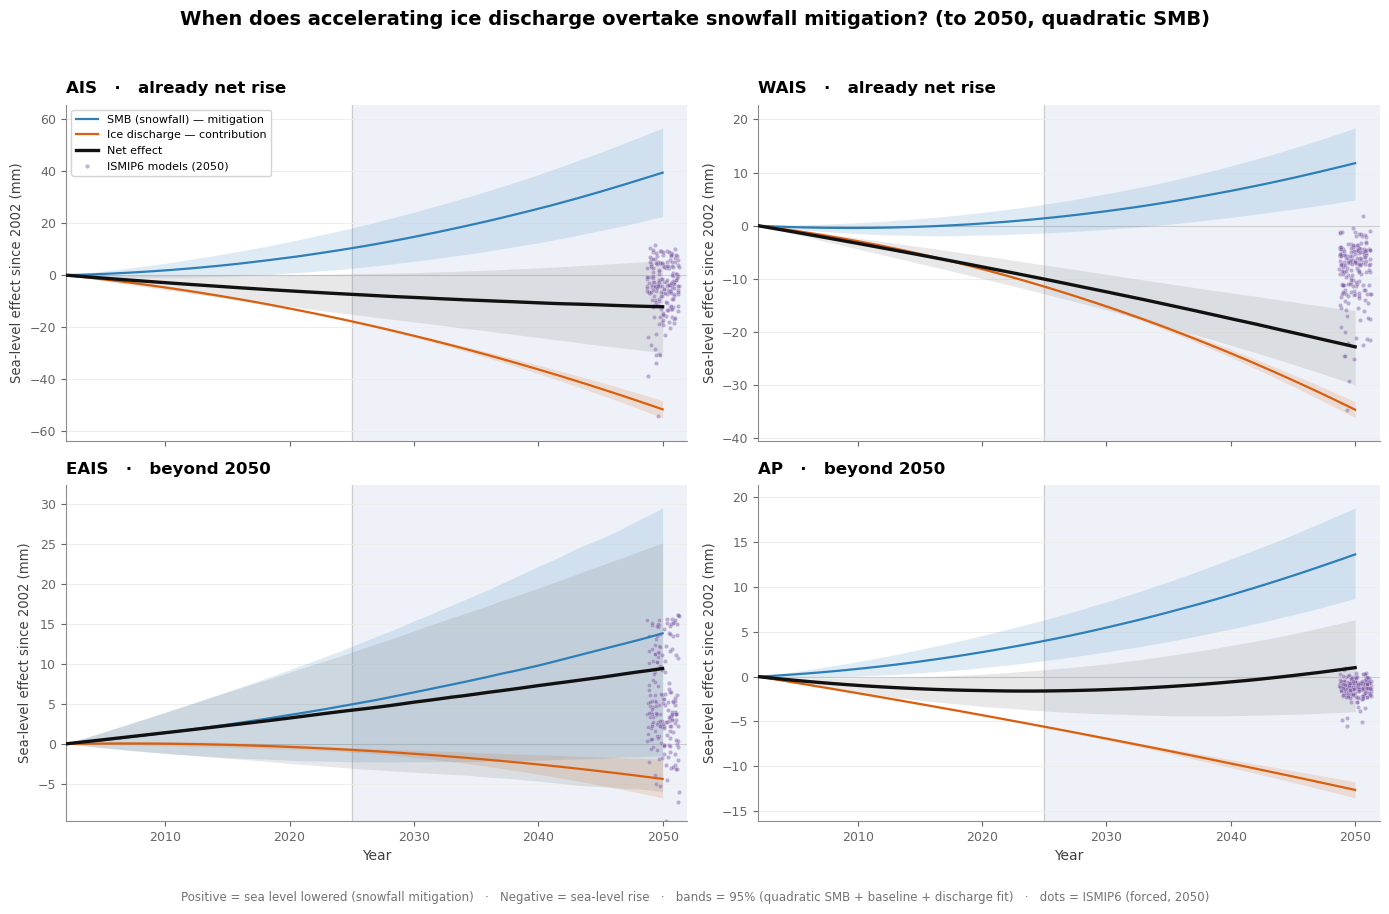

In [71]:
# ===== Mitigation cross-over to 2050 — QUADRATIC SMB (+ discharge fit) =====
from matplotlib.lines import Line2D
GT = GT_PER_MM; TARGET = 2050; N_MC = 4000
region_idx = {"AIS":0,"WAIS":1,"EAIS":2,"AP":3}
C_SMB, C_DIS, C_NET, C_IS = "#2C7FB8", "#D95F0E", "#111111", "#7B5AA6"
def baseline_mean(r):
    return pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]]).loc[1801:1900].mean()
def baseline_error(r):
    k = region_idx[r]; ib = [y-1801 for y in range(1801, 1901)]
    return smb_reg_ens[ib, :, k].mean(0).std(ddof=1)
def polyfit_cov(t, y, deg):                                   # coeffs (high→low power) + covariance
    X = np.vander(t, deg+1); beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta; dof = max(len(t)-(deg+1), 1); s2 = (resid @ resid)/dof
    return beta, s2 * np.linalg.inv(X.T @ X)

ismip = pd.read_csv(os.path.expanduser("~/DataFiles/ISMIP6/ismip6_mass_Gt.csv"))
rng = np.random.default_rng(0); _jit = np.random.default_rng(1)
allyr = np.arange(2002, TARGET+1); T = (allyr-2002).astype(float)
hist = np.arange(2002, 2026); th = (hist-2002).astype(float)
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
print(f"{'reg':<5}{'crossover (median [5–95])':>28}")
for i, (ax, r) in enumerate(zip(axes.ravel(), region_names)):
    B = baseline_mean(r); sig_base = baseline_error(r)
    smb = raw_series[r].loc[2002:2025]
    red_obs = (smb - B).cumsum(); red_obs = (red_obs - red_obs.iloc[0]).values
    g = grace_annual(grace_masks[r]).reindex(hist); black = (g - g.loc[2002]).values
    green_obs = black - red_obs
    qc, qcov = polyfit_cov(th, red_obs, 2)                    # SMB quadratic (only)
    gc, gcov = polyfit_cov(th, green_obs, 2)                  # discharge quadratic

    smb_c = rng.multivariate_normal(qc, qcov, N_MC)          # SMB from quadratic fit covariance
    smb_c[:, 1] += rng.normal(0, sig_base, N_MC)             # baseline uncertainty on the rate
    dis_c = rng.multivariate_normal(gc, gcov, N_MC)          # discharge fit covariance
    tot_c = smb_c + dis_c

    mit_s = (smb_c[:,0:1]*T**2 + smb_c[:,1:2]*T + smb_c[:,2:3]) / GT
    dis_s = (dis_c[:,0:1]*T**2 + dis_c[:,1:2]*T + dis_c[:,2:3]) / GT
    mit_s -= mit_s[:, [0]]; dis_s -= dis_s[:, [0]]; net_s = mit_s + dis_s      # anchor to 0 at 2002
    cross = 2002 - tot_c[:,1] / (2*tot_c[:,0])                                 # turning point year, τ=-B/2A
    good = (tot_c[:,0] < 0)
    valid = good & (cross >= 2002) & (cross <= TARGET)
    if valid.mean() > 0.4:
        cm, clo, chi = np.percentile(cross[valid], [50, 5, 95]); cross_txt = f"crossover {cm:.0f} [{clo:.0f}–{chi:.0f}]"
    else:
        cross_txt = "already net rise" if np.median(cross[good]) < 2002 else "beyond 2050"

    P = lambda a, q: np.percentile(a, q, axis=0)
    ax.axvspan(2025, TARGET+2, color="#eef2f8", zorder=0)
    ax.axvline(2025, color="0.8", lw=0.9, zorder=0.5); ax.axhline(0, color="0.8", lw=0.8, zorder=1)
    ax.fill_between(allyr, P(mit_s,2.5), P(mit_s,97.5), color=C_SMB, alpha=0.15, lw=0, zorder=2)
    ax.fill_between(allyr, P(dis_s,2.5), P(dis_s,97.5), color=C_DIS, alpha=0.15, lw=0, zorder=2)
    ax.fill_between(allyr, P(net_s,2.5), P(net_s,97.5), color="0.5", alpha=0.18, lw=0, zorder=2)
    ax.plot(allyr, P(mit_s,50), color=C_SMB, lw=1.6, zorder=4, label="SMB (snowfall) — mitigation")
    ax.plot(allyr, P(dis_s,50), color=C_DIS, lw=1.6, zorder=4, label="Ice discharge — contribution")
    ax.plot(allyr, P(net_s,50), color=C_NET, lw=2.4, zorder=5, label="Net effect")

    gser = grace_annual(grace_masks[r]); g2016 = gser.loc[2016] - gser.loc[2002]
    ismip_v = (g2016 + ismip[f"{r}_2050"].values) / GT
    lbl = "ISMIP6 models (2050)" if i == 0 else None
    ax.scatter(2050 + _jit.uniform(-1.3, 1.3, len(ismip_v)), ismip_v, s=10, color=C_IS,
               alpha=0.45, edgecolor="white", linewidth=0.3, zorder=3, label=lbl)

    i5, i95 = np.percentile(ismip_v, [5, 95])
    lo = np.min([P(mit_s,2.5).min(), P(dis_s,2.5).min(), P(net_s,2.5).min(), i5])
    hi = np.max([P(mit_s,97.5).max(), P(dis_s,97.5).max(), P(net_s,97.5).max(), i95])
    pad = 0.08*(hi-lo); ax.set_ylim(lo-pad, hi+pad); ax.set_xlim(2002, 2052)
    ax.set_title(f"{r}   ·   {cross_txt}", fontweight="bold", fontsize=12, loc="left", pad=8)
    ax.grid(axis="y", color="0.93", lw=0.7); ax.set_axisbelow(True)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"): ax.spines[sp].set_color("0.55")
    ax.tick_params(labelsize=9, colors="0.4")
    ax.set_ylabel("Sea-level effect since 2002 (mm)", fontsize=9.5, color="0.25")
    print(f"{r:<5}{cross_txt:>28}")
for ax in axes[-1, :]: ax.set_xlabel("Year", fontsize=10, color="0.25")
axes[0,0].legend(fontsize=8, loc="best", framealpha=0.85)
fig.suptitle("When does accelerating ice discharge overtake snowfall mitigation? (to 2050, quadratic SMB)",
             fontsize=14, fontweight="bold", y=0.995)
fig.text(0.5, 0.005, "Positive = sea level lowered (snowfall mitigation)   ·   Negative = sea-level rise   ·   "
         "bands = 95% (quadratic SMB + baseline + discharge fit)   ·   dots = ISMIP6 (forced, 2050)",
         ha="center", fontsize=8.5, color="0.45")
fig.tight_layout(rect=[0, 0.03, 1, 0.97]); plt.show()


reg     crossover (median [5–95])
AIS              already net rise
WAIS             already net rise
EAIS                  beyond 2050
AP                    beyond 2050


/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


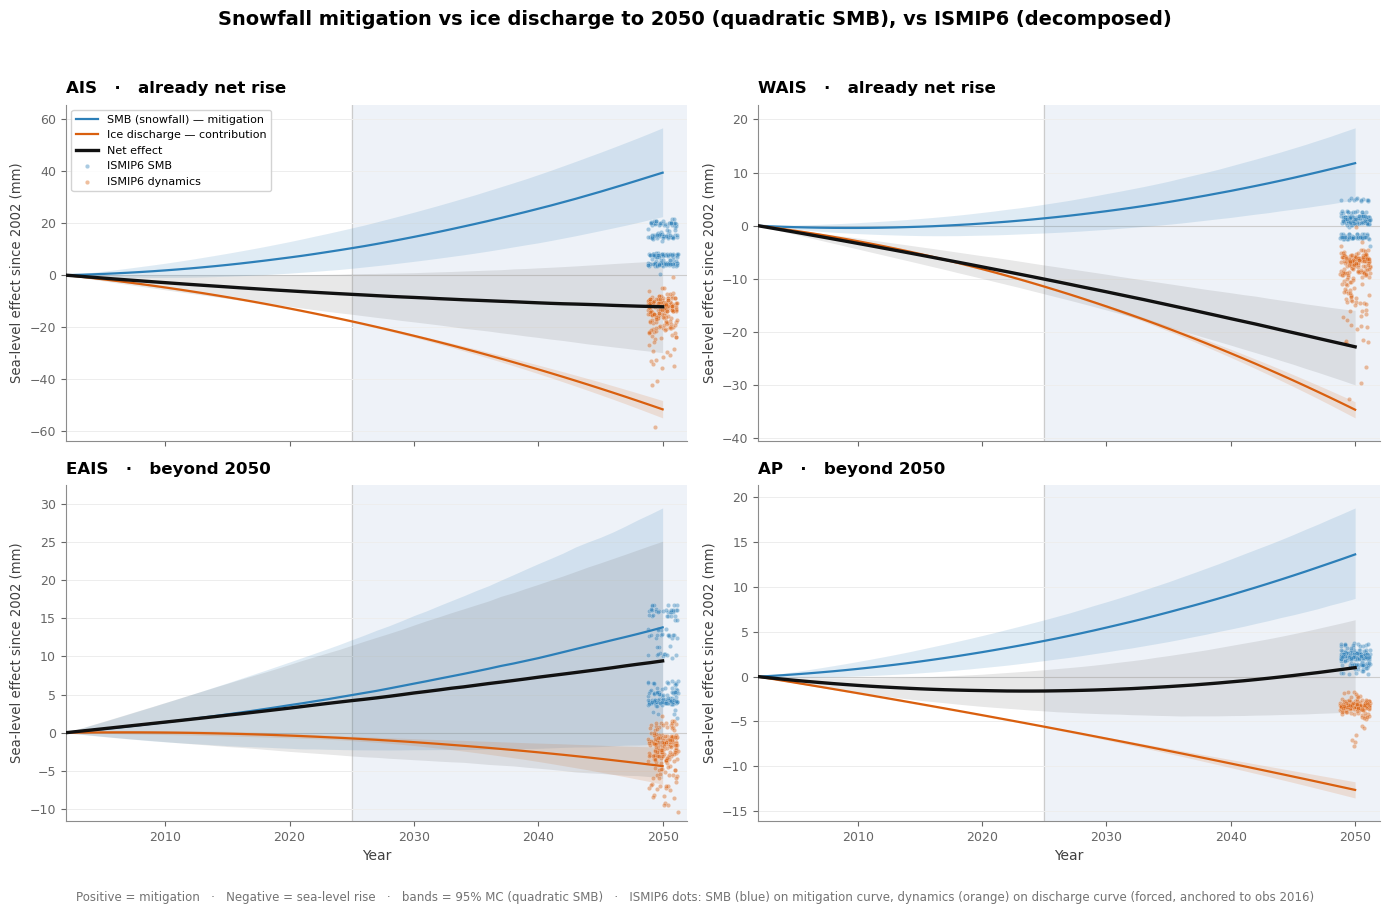

In [70]:
# ===== Mitigation cross-over to 2050 (QUADRATIC SMB) + ISMIP6 decomposed (SMB blue, dynamics orange) =====
from matplotlib.lines import Line2D
GT = GT_PER_MM; TARGET = 2050; N_MC = 4000
region_idx = {"AIS":0,"WAIS":1,"EAIS":2,"AP":3}
C_SMB, C_DIS, C_NET = "#2C7FB8", "#D95F0E", "#111111"
def baseline_mean(r):
    return pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]]).loc[1801:1900].mean()
def baseline_error(r):
    k = region_idx[r]; ib = [y-1801 for y in range(1801, 1901)]
    return smb_reg_ens[ib, :, k].mean(0).std(ddof=1)
def polyfit_cov(t, y, deg):
    X = np.vander(t, deg+1); beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta; dof = max(len(t)-(deg+1), 1); s2 = (resid @ resid)/dof
    return beta, s2 * np.linalg.inv(X.T @ X)

ismip = pd.read_csv(os.path.expanduser("~/DataFiles/ISMIP6/ismip6_decomp_Gt.csv"))
rng = np.random.default_rng(0); _jit = np.random.default_rng(1)
allyr = np.arange(2002, TARGET+1); T = (allyr-2002).astype(float)
hist = np.arange(2002, 2026); th = (hist-2002).astype(float); i16 = int(np.where(hist == 2016)[0][0])
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
print(f"{'reg':<5}{'crossover (median [5–95])':>28}")
for i, (ax, r) in enumerate(zip(axes.ravel(), region_names)):
    B = baseline_mean(r); sig_base = baseline_error(r)
    smb = raw_series[r].loc[2002:2025]
    red_obs = (smb - B).cumsum(); red_obs = (red_obs - red_obs.iloc[0]).values
    g = grace_annual(grace_masks[r]).reindex(hist); black = (g - g.loc[2002]).values
    green_obs = black - red_obs
    qc, qcov = polyfit_cov(th, red_obs, 2)                   # SMB quadratic (only)
    gc, gcov = polyfit_cov(th, green_obs, 2)                 # discharge quadratic

    smb_c = rng.multivariate_normal(qc, qcov, N_MC)          # SMB from quadratic fit covariance
    smb_c[:, 1] += rng.normal(0, sig_base, N_MC)             # baseline uncertainty on the rate
    dis_c = rng.multivariate_normal(gc, gcov, N_MC); tot_c = smb_c + dis_c

    mit_s = (smb_c[:,0:1]*T**2 + smb_c[:,1:2]*T + smb_c[:,2:3]) / GT
    dis_s = (dis_c[:,0:1]*T**2 + dis_c[:,1:2]*T + dis_c[:,2:3]) / GT
    mit_s -= mit_s[:, [0]]; dis_s -= dis_s[:, [0]]; net_s = mit_s + dis_s
    cross = 2002 - tot_c[:,1] / (2*tot_c[:,0]); good = (tot_c[:,0] < 0)
    valid = good & (cross >= 2002) & (cross <= TARGET)
    if valid.mean() > 0.4:
        cm, clo, chi = np.percentile(cross[valid], [50, 5, 95]); cross_txt = f"crossover {cm:.0f} [{clo:.0f}–{chi:.0f}]"
    else:
        cross_txt = "already net rise" if np.median(cross[good]) < 2002 else "beyond 2050"

    P = lambda a, q: np.percentile(a, q, axis=0)
    ax.axvspan(2025, TARGET+2, color="#eef2f8", zorder=0)
    ax.axvline(2025, color="0.8", lw=0.9, zorder=0.5); ax.axhline(0, color="0.8", lw=0.8, zorder=1)
    ax.fill_between(allyr, P(mit_s,2.5), P(mit_s,97.5), color=C_SMB, alpha=0.15, lw=0, zorder=2)
    ax.fill_between(allyr, P(dis_s,2.5), P(dis_s,97.5), color=C_DIS, alpha=0.15, lw=0, zorder=2)
    ax.fill_between(allyr, P(net_s,2.5), P(net_s,97.5), color="0.5", alpha=0.18, lw=0, zorder=2)
    ax.plot(allyr, P(mit_s,50), color=C_SMB, lw=1.6, zorder=4, label="SMB (snowfall) — mitigation")
    ax.plot(allyr, P(dis_s,50), color=C_DIS, lw=1.6, zorder=4, label="Ice discharge — contribution")
    ax.plot(allyr, P(net_s,50), color=C_NET, lw=2.4, zorder=5, label="Net effect")

    # ISMIP6 decomposed dots at 2050, anchored to observed 2016 mit/discharge
    mit16 = red_obs[i16]/GT; dis16 = green_obs[i16]/GT
    smb_dots = mit16 + ismip[f"{r}_smb_2050"].values / GT
    dyn_dots = dis16 + ismip[f"{r}_dyn_2050"].values / GT
    ax.scatter(2050 + _jit.uniform(-1.2, 1.2, len(smb_dots)), smb_dots, s=10, color=C_SMB,
               alpha=0.40, edgecolor="white", linewidth=0.3, zorder=3, label=("ISMIP6 SMB" if i==0 else None))
    ax.scatter(2050 + _jit.uniform(-1.2, 1.2, len(dyn_dots)), dyn_dots, s=10, color=C_DIS,
               alpha=0.40, edgecolor="white", linewidth=0.3, zorder=3, label=("ISMIP6 dynamics" if i==0 else None))

    s5, s95 = np.percentile(smb_dots, [5, 95]); d5, d95 = np.percentile(dyn_dots, [5, 95])
    lo = np.min([P(mit_s,2.5).min(), P(dis_s,2.5).min(), P(net_s,2.5).min(), d5, s5])
    hi = np.max([P(mit_s,97.5).max(), P(dis_s,97.5).max(), P(net_s,97.5).max(), s95, d95])
    pad = 0.08*(hi-lo); ax.set_ylim(lo-pad, hi+pad); ax.set_xlim(2002, 2052)
    ax.set_title(f"{r}   ·   {cross_txt}", fontweight="bold", fontsize=12, loc="left", pad=8)
    ax.grid(axis="y", color="0.93", lw=0.7); ax.set_axisbelow(True)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"): ax.spines[sp].set_color("0.55")
    ax.tick_params(labelsize=9, colors="0.4"); ax.set_ylabel("Sea-level effect since 2002 (mm)", fontsize=9.5, color="0.25")
    print(f"{r:<5}{cross_txt:>28}")
for ax in axes[-1, :]: ax.set_xlabel("Year", fontsize=10, color="0.25")
axes[0,0].legend(fontsize=8, loc="best", framealpha=0.85)
fig.suptitle("Snowfall mitigation vs ice discharge to 2050 (quadratic SMB), vs ISMIP6 (decomposed)",
             fontsize=14, fontweight="bold", y=0.995)
fig.text(0.5, 0.005, "Positive = mitigation   ·   Negative = sea-level rise   ·   bands = 95% MC (quadratic SMB)   ·   "
         "ISMIP6 dots: SMB (blue) on mitigation curve, dynamics (orange) on discharge curve (forced, anchored to obs 2016)",
         ha="center", fontsize=8.5, color="0.45")
fig.tight_layout(rect=[0, 0.03, 1, 0.97]); plt.show()


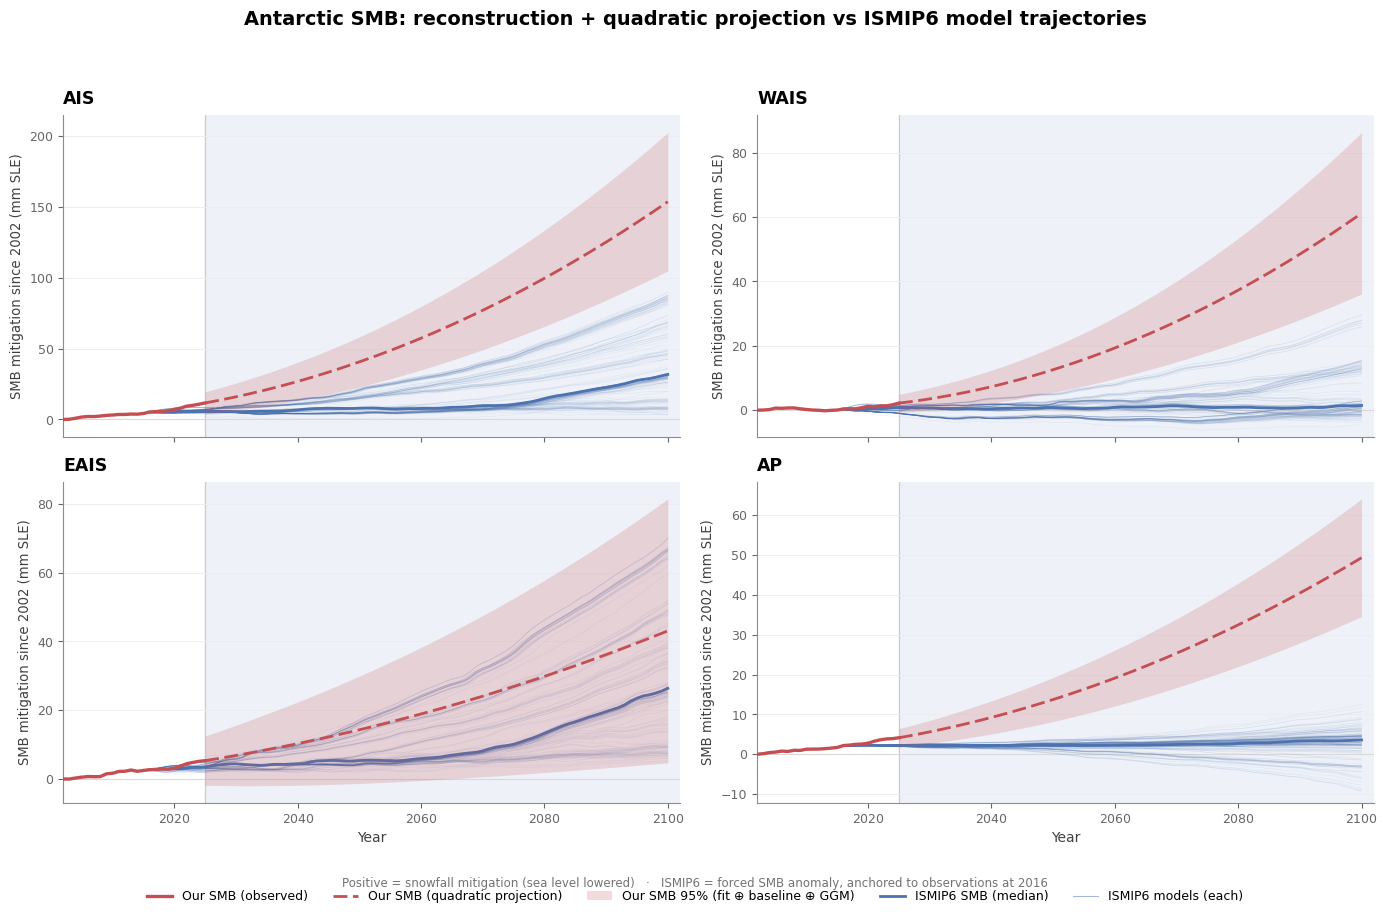

In [75]:
# ===== SMB spaghetti: our reconstruction + QUADRATIC projection vs each ISMIP6 model trajectory =====
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
GT = GT_PER_MM; TARGET = 2100
region_idx = {"AIS":0,"WAIS":1,"EAIS":2,"AP":3}
C_IS, C_OURS = "#4C72B0", "#C44E52"
def baseline_mean(r):
    return pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]]).loc[1801:1900].mean()
def baseline_error(r):
    k = region_idx[r]; ib = [y-1801 for y in range(1801, 1901)]
    return smb_reg_ens[ib, :, k].mean(0).std(ddof=1)
def fit_extrap(t_h, y_h, t_f, deg, t_a, y_a):
    Xh = np.vander(t_h, deg+1); beta, *_ = np.linalg.lstsq(Xh, y_h, rcond=None)
    resid = y_h - Xh @ beta; dof = max(len(t_h)-(deg+1), 1); s2 = (resid @ resid)/dof
    cov = s2 * np.linalg.inv(Xh.T @ Xh)
    D = np.vander(t_f, deg+1) - np.vander([t_a], deg+1)
    return D @ beta + y_a, np.sqrt(np.maximum(np.einsum('ij,jk,ik->i', D, cov, D), 0))
def ggm_cum_sigma(fit, n):
    if n < 1: return 0.0
    R = _toeplitz(_ggm_acf(fit["kappa"], fit["phi"], n) * fit["sigma_w"]**2)
    o = np.ones(n); return float(np.sqrt(o @ R @ o))

traj = np.load(os.path.expanduser("~/DataFiles/ISMIP6/ismip6_smb_traj.npz"), allow_pickle=True)
iyears = traj["years"]
hist = np.arange(2002, 2026); th = (hist-2002).astype(float)
fut = np.arange(2025, TARGET+1); tfa = (fut-2002).astype(float)
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for i, (ax, r) in enumerate(zip(axes.ravel(), region_names)):
    B = baseline_mean(r); sig_base = baseline_error(r)
    smb = raw_series[r].loc[2002:2025]
    red_obs = (smb - B).cumsum(); red_obs = (red_obs - red_obs.iloc[0]).values
    mit_obs = red_obs / GT
    mit16 = mit_obs[int(np.where(hist == 2016)[0][0])]
    rl, sl = fit_extrap(th, red_obs, tfa, 2, th[-1], red_obs[-1])    # QUADRATIC projection
    base_f = sig_base*(fut-2002); ggm = np.array([ggm_cum_sigma(ggm_fits[r], k) for k in range(len(fut))])
    band = 1.96*np.sqrt(sl**2 + base_f**2 + ggm**2) / GT
    mit_proj = rl / GT
    iy_traj = mit16 + traj[r] / GT

    ax.axvspan(2025, TARGET+2, color="#eef2f8", zorder=0)
    ax.axvline(2025, color="0.8", lw=0.9, zorder=0.5); ax.axhline(0, color="0.85", lw=0.8, zorder=1)
    for j in range(iy_traj.shape[0]):
        ax.plot(iyears, iy_traj[j], color=C_IS, lw=0.4, alpha=0.09, zorder=2)
    ax.plot(iyears, np.median(iy_traj, axis=0), color=C_IS, lw=2.0, zorder=4)
    ax.fill_between(fut, mit_proj-band, mit_proj+band, color=C_OURS, alpha=0.20, lw=0, zorder=5)
    ax.plot(hist, mit_obs, color=C_OURS, lw=2.4, zorder=6)
    ax.plot(fut, mit_proj, color=C_OURS, lw=2.0, ls=(0,(5,2)), zorder=6)

    hi = max((mit_proj+band).max(), np.percentile(iy_traj[:,-1], 98))
    lo = min(mit_obs.min(), (mit_proj-band).min(), np.percentile(iy_traj[:,-1], 2))
    pad = 0.06*(hi-lo); ax.set_ylim(lo-pad, hi+pad); ax.set_xlim(2002, TARGET+2)
    ax.set_title(r, fontweight="bold", fontsize=12.5, loc="left", pad=8)
    ax.grid(axis="y", color="0.93", lw=0.7); ax.set_axisbelow(True)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"): ax.spines[sp].set_color("0.55")
    ax.tick_params(labelsize=9, colors="0.4"); ax.set_ylabel("SMB mitigation since 2002 (mm SLE)", fontsize=9.5, color="0.25")
for ax in axes[-1, :]: ax.set_xlabel("Year", fontsize=10, color="0.25")
handles = [
    Line2D([0],[0], color=C_OURS, lw=2.4, label="Our SMB (observed)"),
    Line2D([0],[0], color=C_OURS, lw=2.0, ls=(0,(5,2)), label="Our SMB (quadratic projection)"),
    Patch(facecolor=C_OURS, alpha=0.20, label="Our SMB 95% (fit ⊕ baseline ⊕ GGM)"),
    Line2D([0],[0], color=C_IS, lw=2.0, label="ISMIP6 SMB (median)"),
    Line2D([0],[0], color=C_IS, lw=0.8, alpha=0.5, label="ISMIP6 models (each)"),
]
fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Antarctic SMB: reconstruction + quadratic projection vs ISMIP6 model trajectories",
             fontsize=14, fontweight="bold", y=0.995)
fig.text(0.5, 0.02, "Positive = snowfall mitigation (sea level lowered)   ·   ISMIP6 = forced SMB anomaly, anchored to observations at 2016",
         ha="center", fontsize=8.5, color="0.45")
fig.tight_layout(rect=[0, 0.05, 1, 0.96]); plt.show()


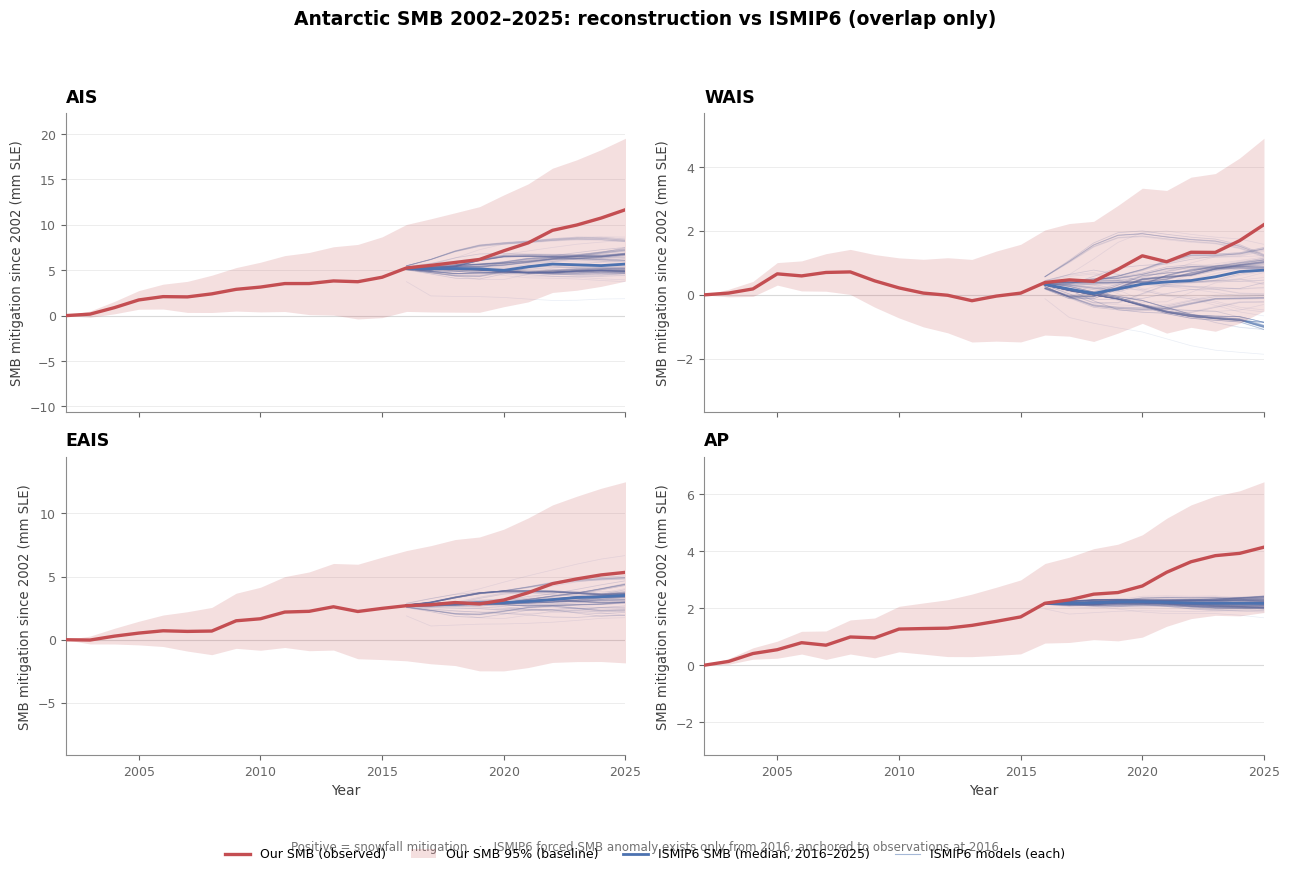

In [76]:
# ===== SMB, observed 2002–2025 only: our reconstruction vs ISMIP6 overlap =====
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
GT = GT_PER_MM
region_idx = {"AIS":0,"WAIS":1,"EAIS":2,"AP":3}
C_IS, C_OURS = "#4C72B0", "#C44E52"
def baseline_mean(r):
    return pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]]).loc[1801:1900].mean()
def baseline_error(r):
    k = region_idx[r]; ib = [y-1801 for y in range(1801, 1901)]
    return smb_reg_ens[ib, :, k].mean(0).std(ddof=1)

traj = np.load(os.path.expanduser("~/DataFiles/ISMIP6/ismip6_smb_traj.npz"), allow_pickle=True)
iyears = traj["years"]; m25 = iyears <= 2025                       # ISMIP6 overlap with obs period
hist = np.arange(2002, 2026)
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), sharex=True)
for i, (ax, r) in enumerate(zip(axes.ravel(), region_names)):
    B = baseline_mean(r); sig_base = baseline_error(r)
    smb = raw_series[r].loc[2002:2025]
    red_obs = (smb - B).cumsum(); red_obs = (red_obs - red_obs.iloc[0]).values
    mit_obs = red_obs / GT
    band = 1.96 * sig_base * (hist - 2002) / GT                    # baseline 95%
    mit16 = mit_obs[int(np.where(hist == 2016)[0][0])]
    iy_traj = mit16 + traj[r][:, m25] / GT                          # ISMIP6 over 2016–2025, anchored

    ax.axhline(0, color="0.85", lw=0.8, zorder=1)
    for j in range(iy_traj.shape[0]):
        ax.plot(iyears[m25], iy_traj[j], color=C_IS, lw=0.5, alpha=0.12, zorder=2)
    ax.plot(iyears[m25], np.median(iy_traj, axis=0), color=C_IS, lw=2.0, zorder=4)
    ax.fill_between(hist, mit_obs-band, mit_obs+band, color=C_OURS, alpha=0.18, lw=0, zorder=3)
    ax.plot(hist, mit_obs, color=C_OURS, lw=2.4, zorder=5)

    lo = min(mit_obs.min()-band.max(), iy_traj.min()); hi = max(mit_obs.max()+band.max(), iy_traj.max())
    pad = 0.10*(hi-lo); ax.set_ylim(lo-pad, hi+pad); ax.set_xlim(2002, 2025)
    ax.set_title(r, fontweight="bold", fontsize=12.5, loc="left", pad=8)
    ax.grid(axis="y", color="0.93", lw=0.7); ax.set_axisbelow(True)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"): ax.spines[sp].set_color("0.55")
    ax.tick_params(labelsize=9, colors="0.4"); ax.set_ylabel("SMB mitigation since 2002 (mm SLE)", fontsize=9.5, color="0.25")
for ax in axes[-1, :]: ax.set_xlabel("Year", fontsize=10, color="0.25")
handles = [
    Line2D([0],[0], color=C_OURS, lw=2.4, label="Our SMB (observed)"),
    Patch(facecolor=C_OURS, alpha=0.18, label="Our SMB 95% (baseline)"),
    Line2D([0],[0], color=C_IS, lw=2.0, label="ISMIP6 SMB (median, 2016–2025)"),
    Line2D([0],[0], color=C_IS, lw=0.8, alpha=0.5, label="ISMIP6 models (each)"),
]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Antarctic SMB 2002–2025: reconstruction vs ISMIP6 (overlap only)",
             fontsize=13.5, fontweight="bold", y=0.995)
fig.text(0.5, 0.005, "Positive = snowfall mitigation   ·   ISMIP6 forced SMB anomaly exists only from 2016, anchored to observations at 2016",
         ha="center", fontsize=8.5, color="0.45")
fig.tight_layout(rect=[0, 0.05, 1, 0.96]); plt.show()


reg    % quad   crossover (median [5–95])
AIS       83%            already net rise
WAIS      50%            already net rise
EAIS      34%  crossover 2049 [2011–2092]
AP        59%            already net rise


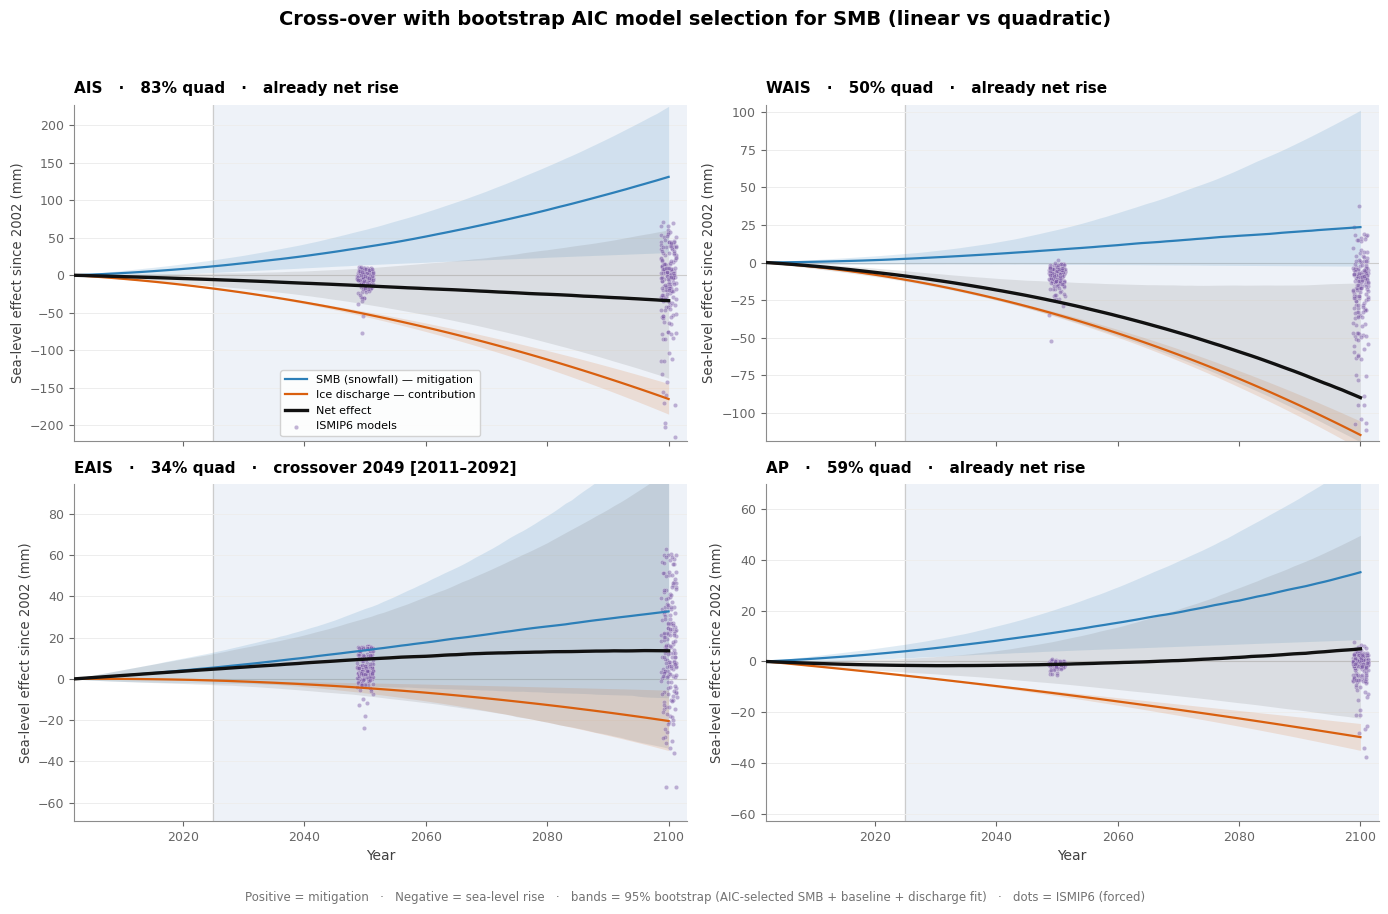

In [82]:
# ===== Cross-over with BOOTSTRAP + AIC model selection for SMB (linear vs quadratic) =====
from matplotlib.lines import Line2D
GT = GT_PER_MM; TARGET = 2100; N_BOOT = 4000
region_idx = {"AIS":0,"WAIS":1,"EAIS":2,"AP":3}
C_SMB, C_DIS, C_NET, C_IS = "#2C7FB8", "#D95F0E", "#111111", "#7B5AA6"
def baseline_mean(r):
    return pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]]).loc[1801:1900].mean()
def baseline_error(r):
    k = region_idx[r]; ib = [y-1801 for y in range(1801, 1901)]
    return smb_reg_ens[ib, :, k].mean(0).std(ddof=1)
def polyfit_cov(t, y, deg):
    X = np.vander(t, deg+1); beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta; dof = max(len(t)-(deg+1), 1); s2 = (resid @ resid)/dof
    return beta, s2 * np.linalg.inv(X.T @ X)
aic = lambda rss, n, k: n*np.log(rss/n + 1e-12) + 2*k

ismip = pd.read_csv(os.path.expanduser("~/DataFiles/ISMIP6/ismip6_mass_Gt.csv"))
rng = np.random.default_rng(0); _jit = np.random.default_rng(1)
allyr = np.arange(2002, TARGET+1); T = (allyr-2002).astype(float); idx50 = int(np.searchsorted(allyr, 2050))
hist = np.arange(2002, 2026); th = (hist-2002).astype(float); n = len(th)
X1 = np.vander(th, 2); pinv1 = np.linalg.inv(X1.T@X1) @ X1.T          # deg-1 (linear) fit operator
X2 = np.vander(th, 3); pinv2 = np.linalg.inv(X2.T@X2) @ X2.T          # deg-2 (quadratic) fit operator
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
print(f"{'reg':<5}{'% quad':>8}{'crossover (median [5–95])':>28}")
for i, (ax, r) in enumerate(zip(axes.ravel(), region_names)):
    B = baseline_mean(r); sig_base = baseline_error(r)
    smb_a = (raw_series[r].loc[2002:2025] - B).values                 # annual SMB anomaly (rate)
    g = grace_annual(grace_masks[r]).reindex(hist); black = (g - g.loc[2002]).values
    red_obs = np.cumsum(smb_a); red_obs -= red_obs[0]
    green_obs = black - red_obs
    gc, gcov = polyfit_cov(th, green_obs, 2)                          # discharge quadratic

    # residual bootstrap of the annual rate (under deg-1) + baseline draw
    br = pinv1 @ smb_a; resid_r = smb_a - X1 @ br
    a_b = (X1 @ br)[None,:] + resid_r[rng.integers(0, n, (N_BOOT, n))] + rng.normal(0, sig_base, (N_BOOT,1))
    # AIC on the rate: constant (deg-0) vs linear (deg-1)  ->  linear vs quadratic cumulative
    c0 = a_b.mean(1); rss0 = ((a_b - c0[:,None])**2).sum(1)
    fit1 = (a_b @ pinv1.T) @ X1.T; rss1 = ((a_b - fit1)**2).sum(1)
    sel_quad = aic(rss1, n, 2) < aic(rss0, n, 1)
    # cumulative fit of the selected degree
    red_b = np.cumsum(a_b, axis=1); red_b -= red_b[:, [0]]
    bc1 = red_b @ pinv1.T; bc2 = red_b @ pinv2.T
    smb_coef = np.zeros((N_BOOT, 3))
    smb_coef[sel_quad] = bc2[sel_quad]; smb_coef[~sel_quad, 1:] = bc1[~sel_quad]
    dis_coef = rng.multivariate_normal(gc, gcov, N_BOOT); tot_coef = smb_coef + dis_coef

    mit_s = (smb_coef[:,0:1]*T**2 + smb_coef[:,1:2]*T + smb_coef[:,2:3]) / GT
    dis_s = (dis_coef[:,0:1]*T**2 + dis_coef[:,1:2]*T + dis_coef[:,2:3]) / GT
    mit_s -= mit_s[:, [0]]; dis_s -= dis_s[:, [0]]; net_s = mit_s + dis_s
    cross = 2002 - tot_coef[:,1] / (2*tot_coef[:,0]); good = tot_coef[:,0] < 0
    valid = good & (cross >= 2002) & (cross <= TARGET)
    if valid.mean() > 0.4:
        cm, clo, chi = np.percentile(cross[valid], [50, 5, 95]); cross_txt = f"crossover {cm:.0f} [{clo:.0f}–{chi:.0f}]"
    else:
        cross_txt = "already net rise" if np.median(cross[good]) < 2002 else "beyond 2100"

    P = lambda a, q: np.percentile(a, q, axis=0)
    ax.axvspan(2025, TARGET+3, color="#eef2f8", zorder=0)
    ax.axvline(2025, color="0.8", lw=0.9, zorder=0.5); ax.axhline(0, color="0.8", lw=0.8, zorder=1)
    ax.fill_between(allyr, P(mit_s,2.5), P(mit_s,97.5), color=C_SMB, alpha=0.15, lw=0, zorder=2)
    ax.fill_between(allyr, P(dis_s,2.5), P(dis_s,97.5), color=C_DIS, alpha=0.15, lw=0, zorder=2)
    ax.fill_between(allyr, P(net_s,2.5), P(net_s,97.5), color="0.5", alpha=0.18, lw=0, zorder=2)
    ax.plot(allyr, P(mit_s,50), color=C_SMB, lw=1.6, zorder=4, label="SMB (snowfall) — mitigation")
    ax.plot(allyr, P(dis_s,50), color=C_DIS, lw=1.6, zorder=4, label="Ice discharge — contribution")
    ax.plot(allyr, P(net_s,50), color=C_NET, lw=2.4, zorder=5, label="Net effect")

    gser = grace_annual(grace_masks[r]); g2016 = gser.loc[2016] - gser.loc[2002]
    for yr in (2050, 2100):
        v = (g2016 + ismip[f"{r}_{yr}"].values) / GT
        lbl = "ISMIP6 models" if (i == 0 and yr == 2050) else None
        ax.scatter(yr + _jit.uniform(-1.3, 1.3, len(v)), v, s=10, color=C_IS, alpha=0.45,
                   edgecolor="white", linewidth=0.3, zorder=3, label=lbl)

    lo = np.min([P(mit_s,2.5)[:idx50].min(), P(dis_s,2.5)[:idx50].min(), P(net_s,2.5)[:idx50].min()])
    hi = np.max([P(mit_s,97.5)[:idx50].max(), P(dis_s,97.5)[:idx50].max(), P(net_s,97.5)[:idx50].max()])
    pad = 1.5*(hi-lo); ax.set_ylim(lo-pad, hi+pad); ax.set_xlim(2002, TARGET+3)
    ax.set_title(f"{r}   ·   {int(round(100*sel_quad.mean()))}% quad   ·   {cross_txt}",
                 fontweight="bold", fontsize=11, loc="left", pad=8)
    ax.grid(axis="y", color="0.93", lw=0.7); ax.set_axisbelow(True)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"): ax.spines[sp].set_color("0.55")
    ax.tick_params(labelsize=9, colors="0.4"); ax.set_ylabel("Sea-level effect since 2002 (mm)", fontsize=9.5, color="0.25")
    print(f"{r:<5}{100*sel_quad.mean():>7.0f}%{cross_txt:>28}")
for ax in axes[-1, :]: ax.set_xlabel("Year", fontsize=10, color="0.25")
axes[0,0].legend(fontsize=8, loc="best", framealpha=0.85)
fig.suptitle("Cross-over with bootstrap AIC model selection for SMB (linear vs quadratic)",
             fontsize=14, fontweight="bold", y=0.995)
fig.text(0.5, 0.005, "Positive = mitigation   ·   Negative = sea-level rise   ·   "
         "bands = 95% bootstrap (AIC-selected SMB + baseline + discharge fit)   ·   dots = ISMIP6 (forced)",
         ha="center", fontsize=8.5, color="0.45")
fig.tight_layout(rect=[0, 0.03, 1, 0.97]); plt.show()


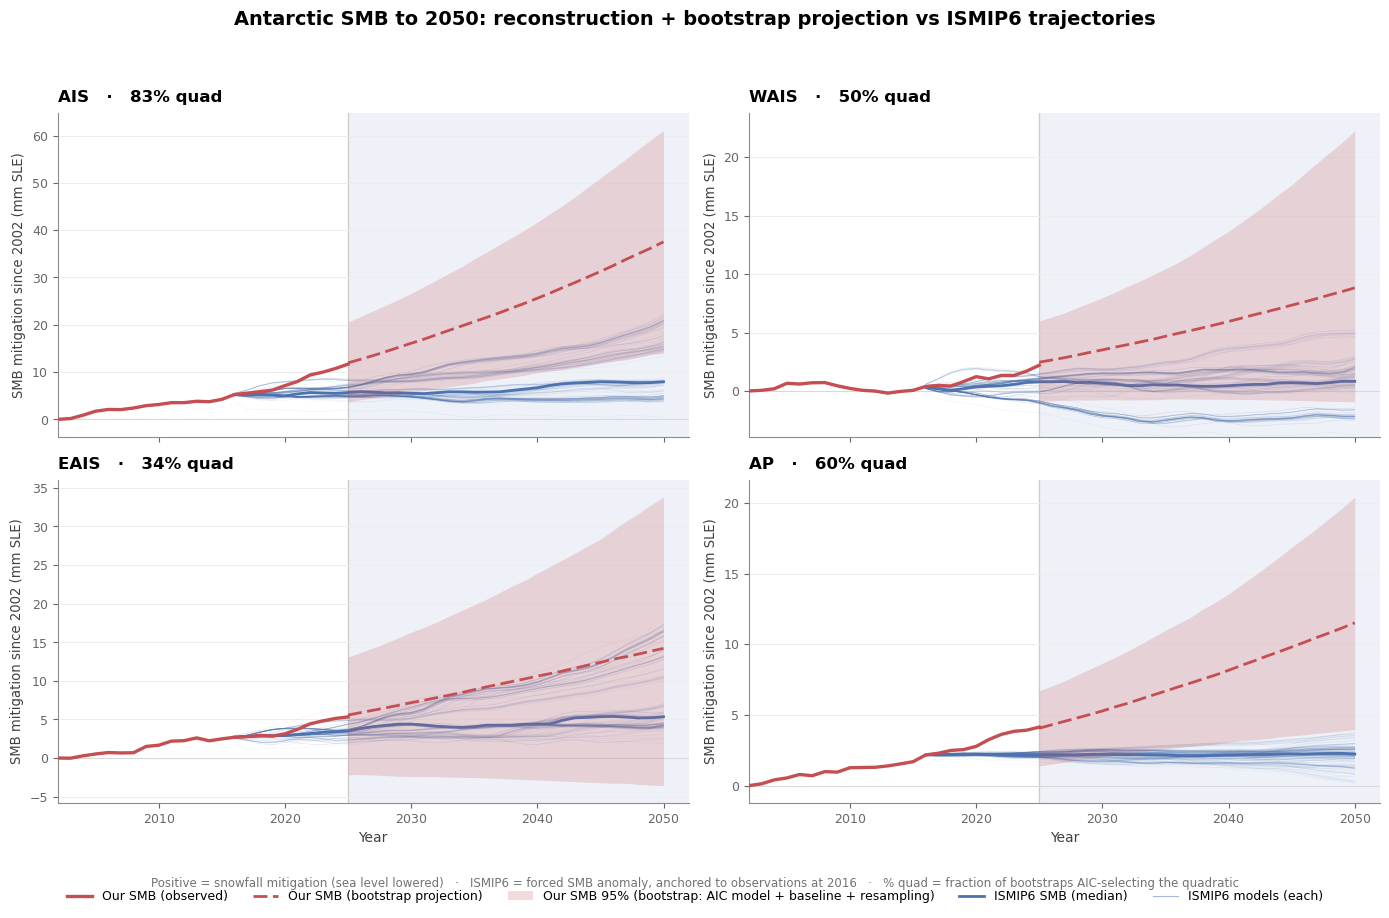

In [85]:
# ===== SMB spaghetti to 2050: reconstruction + BOOTSTRAP-AIC projection vs ISMIP6 trajectories =====
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
GT = GT_PER_MM; TARGET = 2050; N_BOOT = 4000
region_idx = {"AIS":0,"WAIS":1,"EAIS":2,"AP":3}
C_IS, C_OURS = "#4C72B0", "#C44E52"
def baseline_mean(r):
    return pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]]).loc[1801:1900].mean()
def baseline_error(r):
    k = region_idx[r]; ib = [y-1801 for y in range(1801, 1901)]
    return smb_reg_ens[ib, :, k].mean(0).std(ddof=1)
aic = lambda rss, n, k: n*np.log(rss/n + 1e-12) + 2*k

traj = np.load(os.path.expanduser("~/DataFiles/ISMIP6/ismip6_smb_traj.npz"), allow_pickle=True)
iyears = traj["years"]; m50 = iyears <= TARGET                        # ISMIP6 trajectories to 2050 only
rng = np.random.default_rng(0)
allyr = np.arange(2002, TARGET+1); T = (allyr-2002).astype(float); fmask = allyr >= 2025
hist = np.arange(2002, 2026); th = (hist-2002).astype(float); n = len(th)
X1 = np.vander(th, 2); pinv1 = np.linalg.inv(X1.T@X1) @ X1.T
X2 = np.vander(th, 3); pinv2 = np.linalg.inv(X2.T@X2) @ X2.T
P = lambda a, q: np.percentile(a, q, axis=0)
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for i, (ax, r) in enumerate(zip(axes.ravel(), region_names)):
    B = baseline_mean(r); sig_base = baseline_error(r)
    smb_a = (raw_series[r].loc[2002:2025] - B).values
    red_obs = np.cumsum(smb_a); red_obs -= red_obs[0]
    mit_obs = red_obs / GT
    mit16 = mit_obs[int(np.where(hist == 2016)[0][0])]

    br = pinv1 @ smb_a; resid_r = smb_a - X1 @ br
    a_b = (X1 @ br)[None,:] + resid_r[rng.integers(0, n, (N_BOOT, n))] + rng.normal(0, sig_base, (N_BOOT,1))
    c0 = a_b.mean(1); rss0 = ((a_b - c0[:,None])**2).sum(1)
    fit1 = (a_b @ pinv1.T) @ X1.T; rss1 = ((a_b - fit1)**2).sum(1)
    sel_quad = aic(rss1, n, 2) < aic(rss0, n, 1)
    red_b = np.cumsum(a_b, axis=1); red_b -= red_b[:, [0]]
    bc1 = red_b @ pinv1.T; bc2 = red_b @ pinv2.T
    smb_c = np.zeros((N_BOOT, 3)); smb_c[sel_quad] = bc2[sel_quad]; smb_c[~sel_quad, 1:] = bc1[~sel_quad]
    mit_all = (smb_c[:,0:1]*T**2 + smb_c[:,1:2]*T + smb_c[:,2:3]) / GT
    mit_all -= mit_all[:, [0]]
    ayf = allyr[fmask]
    mproj = P(mit_all[:, fmask], 50); mlo = P(mit_all[:, fmask], 2.5); mhi = P(mit_all[:, fmask], 97.5)
    iyy = iyears[m50]; iy_traj = mit16 + traj[r][:, m50] / GT

    ax.axvspan(2025, TARGET+2, color="#eef2f8", zorder=0)
    ax.axvline(2025, color="0.8", lw=0.9, zorder=0.5); ax.axhline(0, color="0.85", lw=0.8, zorder=1)
    for j in range(iy_traj.shape[0]):
        ax.plot(iyy, iy_traj[j], color=C_IS, lw=0.4, alpha=0.09, zorder=2)
    ax.plot(iyy, np.median(iy_traj, axis=0), color=C_IS, lw=2.0, zorder=4)
    ax.fill_between(ayf, mlo, mhi, color=C_OURS, alpha=0.20, lw=0, zorder=5)
    ax.plot(hist, mit_obs, color=C_OURS, lw=2.4, zorder=6)
    ax.plot(ayf, mproj, color=C_OURS, lw=2.0, ls=(0,(5,2)), zorder=6)

    hi = max(mhi.max(), np.percentile(iy_traj[:,-1], 98))
    lo = min(mit_obs.min(), mlo.min(), np.percentile(iy_traj[:,-1], 2))
    pad = 0.06*(hi-lo); ax.set_ylim(lo-pad, hi+pad); ax.set_xlim(2002, TARGET+2)
    ax.set_title(f"{r}   ·   {int(round(100*sel_quad.mean()))}% quad", fontweight="bold", fontsize=12, loc="left", pad=8)
    ax.grid(axis="y", color="0.93", lw=0.7); ax.set_axisbelow(True)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"): ax.spines[sp].set_color("0.55")
    ax.tick_params(labelsize=9, colors="0.4"); ax.set_ylabel("SMB mitigation since 2002 (mm SLE)", fontsize=9.5, color="0.25")
for ax in axes[-1, :]: ax.set_xlabel("Year", fontsize=10, color="0.25")
handles = [
    Line2D([0],[0], color=C_OURS, lw=2.4, label="Our SMB (observed)"),
    Line2D([0],[0], color=C_OURS, lw=2.0, ls=(0,(5,2)), label="Our SMB (bootstrap projection)"),
    Patch(facecolor=C_OURS, alpha=0.20, label="Our SMB 95% (bootstrap: AIC model + baseline + resampling)"),
    Line2D([0],[0], color=C_IS, lw=2.0, label="ISMIP6 SMB (median)"),
    Line2D([0],[0], color=C_IS, lw=0.8, alpha=0.5, label="ISMIP6 models (each)"),
]
fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Antarctic SMB to 2050: reconstruction + bootstrap projection vs ISMIP6 trajectories",
             fontsize=14, fontweight="bold", y=0.995)
fig.text(0.5, 0.02, "Positive = snowfall mitigation (sea level lowered)   ·   ISMIP6 = forced SMB anomaly, anchored to observations at 2016   ·   "
         "% quad = fraction of bootstraps AIC-selecting the quadratic",
         ha="center", fontsize=8.5, color="0.45")
fig.tight_layout(rect=[0, 0.05, 1, 0.96]); plt.show()
